### LSE Data Analytics Online Career Accelerator

# Course 2: Data Analytics using Python

## 1) Assignment activity 1

# NHS: Analysing Staffing and Resource Utilization in the Healthcare Network

### Overview

The United Kingdom has undergone a profound transformation due to the Covid-19 pandemic, impacting various aspects of life, including education, the economy, and the healthcare system. This study specifically delves into the challenges faced by the National Health Service (NHS) between January 2020 and June 2022 in managing the escalating number of Covid-19 cases. Notably, the study places significant emphasis on the obstacles faced, particularly in the aftermath of the easing of Covid-19 restrictions starting from August 2021.

The central focus revolves around aligning infrastructure and resources with the rising demand. The analysis is concentrated on exploring service settings, appointment modes and types, scrutinizing healthcare professionals and appointment trends, assessing resource and capacity utilization, and tackling the issue of missed appointments.
affecting all the aspects of life from our daily lives and education to the economy and healthcare system. This study concentrates specifically on the challenges the National Health Service (NHS) faced between January 2020 and June 2022 in dealing with the increasing number of COVID-19 cases. The study places a particular emphasis on the challenges faced, especially in the aftermath of the easing of Covid-19 restrictions from August 2021 onward. The critical focus is on aligning infrastructure and resources with the escalating demand, a task complicated by differing stakeholder perspectives on whether to expand capacity or maximize the use of existing resources. The primary goal of this study is to offer insights for informed budget decisions, alongside addressing the critical issue of missed general practitioner (GP) appointments to reduce unnecessary costs and enhance financial and social outcomes.

### NHS Objectives

Efficiently allocate resources, address capacity needs, and reduce missed GP appointments to improve the NHS’ effectiveness in England.

> ### Key NHS Inquiries to Address:

**1.** Should the NHS start looking at increasing staff levels? 

**2.** How the healthcare professional types differ over time? 

**3.** Are there significant changes in the attendance of appointments? 

**4.** Are there any trends in time between booking an appointment?

**5.** Are there changes in terms of appointment type and the busiest months?

**6.** How do the various service settings compare?

The analysis focus on historical trends, infrastructure usage, missed appointments, and capacity comparisons, providing key insights into staffing, resource utilization, and appointment management.

## 2) Assignment activity 2

### Prepare your workstation

In [362]:
# Import the necessary libraries.
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Ignore warnings.
import warnings
warnings.filterwarnings('ignore')

# Import and sense-check 'actual_duration.csv' as ad.
ad = pd.read_csv('actual_duration.csv')

# View the DataFrame.
ad

,sub_icb_location_code,sub_icb_location_ons_code,sub_icb_location_name,icb_ons_code,region_ons_code,region_name,appointment_date,actual_duration,count_of_appointments
0,01F,E38000068,NHS Cheshire and Merseyside ICB - 01F,E54000008,E40000010,North West,01-Dec-21,Unknown / Data Quality,1035
1,01F,E38000068,NHS Cheshire and Merseyside ICB - 01F,E54000008,E40000010,North West,01-Dec-21,6-10 Minutes,434
2,01F,E38000068,NHS Cheshire and Merseyside ICB - 01F,E54000008,E40000010,North West,01-Dec-21,31-60 Minutes,95
3,01F,E38000068,NHS Cheshire and Merseyside ICB - 01F,E54000008,E40000010,North West,01-Dec-21,21-30 Minutes,146
4,01F,E38000068,NHS Cheshire and Merseyside ICB - 01F,E54000008,E40000010,North West,01-Dec-21,16-20 Minutes,140
...,...,...,...,...,...,...,...,...,...
137788,D2P2L,E38000259,NHS Black Country ICB - D2P2L,E54000062,E40000011,Midlands,30-Jun-22,11-15 Minutes,3940
137789,D2P2L,E38000259,NHS Black Country ICB - D2P2L,E54000062,E40000011,Midlands,30-Jun-22,6-10 Minutes,4787
137790,D2P2L,E38000259,NHS Black Country ICB - D2P2L,E54000062,E40000011,Midlands,30-Jun-22,16-20 Minutes,2422
137791,D2P2L,E38000259,NHS Black Country ICB - D2P2L,E54000062,E40000011,Midlands,30-Jun-22,21-30 Minutes,2164


In [363]:
# View the column names and data shape.
# 'ad' table' updated by adding two new column:'region_names'
print(ad.shape)
print(ad.columns)

(137793, 9)
Index(['sub_icb_location_code', 'sub_icb_location_ons_code',
       'sub_icb_location_name', 'icb_ons_code', 'region_ons_code',
       'region_name', 'appointment_date', 'actual_duration',
       'count_of_appointments'],
      dtype='object')


In [364]:
# Check for missing values
ad_na = ad[ad.isna().any(axis=1)]
ad_na.shape

(0, 9)

In [365]:
# Determine the data types.
print(ad.dtypes)

sub_icb_location_code        object
sub_icb_location_ons_code    object
sub_icb_location_name        object
icb_ons_code                 object
region_ons_code              object
region_name                  object
appointment_date             object
actual_duration              object
count_of_appointments         int64
dtype: object


In [366]:
# Determine the sum of missing data values.
ad.isnull().sum()

sub_icb_location_code        0
sub_icb_location_ons_code    0
sub_icb_location_name        0
icb_ons_code                 0
region_ons_code              0
region_name                  0
appointment_date             0
actual_duration              0
count_of_appointments        0
dtype: int64

In [367]:
# Examine the "actual_duration" column in the dataset and identify the unknown/data quality issues.
ad.actual_duration.isnull()

0         False
1         False
2         False
3         False
4         False
          ...  
137788    False
137789    False
137790    False
137791    False
137792    False
Name: actual_duration, Length: 137793, dtype: bool

In [368]:
# Determining the sum of missing values in the 'actual_duration column.
ad['actual_duration'].isnull().sum()

0

In [369]:
# Determine the shape of the data set.
print(ad.shape)
print(ad.dtypes)

(137793, 9)
sub_icb_location_code        object
sub_icb_location_ons_code    object
sub_icb_location_name        object
icb_ons_code                 object
region_ons_code              object
region_name                  object
appointment_date             object
actual_duration              object
count_of_appointments         int64
dtype: object


In [370]:
# Check for duplicate entries.
# Print the number of duplicates found. 
print("Duplicate records count in 'ad':", ad.duplicated().sum())

Duplicate records count in 'ad': 0


In [371]:
# Review metadata and descriptive statistics.
ad.describe().round(2)

,count_of_appointments
count,137793.00
mean,1219.08
std,1546.90
min,1.00
25%,194.00
50%,696.00
75%,1621.00
max,15400.00


In [372]:
# Display an overview of the DataFrame information.
ad.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137793 entries, 0 to 137792
Data columns (total 9 columns):
 #   Column                     Non-Null Count   Dtype 
---  ------                     --------------   ----- 
 0   sub_icb_location_code      137793 non-null  object
 1   sub_icb_location_ons_code  137793 non-null  object
 2   sub_icb_location_name      137793 non-null  object
 3   icb_ons_code               137793 non-null  object
 4   region_ons_code            137793 non-null  object
 5   region_name                137793 non-null  object
 6   appointment_date           137793 non-null  object
 7   actual_duration            137793 non-null  object
 8   count_of_appointments      137793 non-null  int64 
dtypes: int64(1), object(8)
memory usage: 9.5+ MB


In [373]:
# Import and sense-check 'appointments_regional.csv' as ar.
ar = pd.read_csv('appointments_regional.csv')

In [374]:
# View the DataFrame.
ar.head()

,icb_ons_code,appointment_month,appointment_status,hcp_type,appointment_mode,time_between_book_and_appointment,count_of_appointments
0,E54000034,2020-01,Attended,GP,Face-to-Face,1 Day,8107
1,E54000034,2020-01,Attended,GP,Face-to-Face,15 to 21 Days,6791
2,E54000034,2020-01,Attended,GP,Face-to-Face,2 to 7 Days,20686
3,E54000034,2020-01,Attended,GP,Face-to-Face,22 to 28 Days,4268
4,E54000034,2020-01,Attended,GP,Face-to-Face,8 to 14 Days,11971


In [375]:
# View the last 5 rows.
ar.tail()

,icb_ons_code,appointment_month,appointment_status,hcp_type,appointment_mode,time_between_book_and_appointment,count_of_appointments
596816,E54000050,2022-06,Unknown,Unknown,Unknown,2 to 7 Days,21
596817,E54000050,2022-06,Unknown,Unknown,Unknown,22 to 28 Days,8
596818,E54000050,2022-06,Unknown,Unknown,Unknown,8 to 14 Days,28
596819,E54000050,2022-06,Unknown,Unknown,Unknown,More than 28 Days,17
596820,E54000050,2022-06,Unknown,Unknown,Unknown,Same Day,10


In [376]:
# Check for missing values.
ar_na = ar[ar.isna().any(axis=1)]
ar_na.shape

(0, 7)

In [377]:
# Determine the sum of missing values.
ar.isnull().sum()

icb_ons_code                         0
appointment_month                    0
appointment_status                   0
hcp_type                             0
appointment_mode                     0
time_between_book_and_appointment    0
count_of_appointments                0
dtype: int64

In [378]:
# Determine the shape of the data set.
print(ar.shape)
print(ar.dtypes)
print(ar.columns)

(596821, 7)
icb_ons_code                         object
appointment_month                    object
appointment_status                   object
hcp_type                             object
appointment_mode                     object
time_between_book_and_appointment    object
count_of_appointments                 int64
dtype: object
Index(['icb_ons_code', 'appointment_month', 'appointment_status', 'hcp_type',
       'appointment_mode', 'time_between_book_and_appointment',
       'count_of_appointments'],
      dtype='object')


In [379]:
# Review metadata and descriptive statistics.
ar.describe().round(2)

,count_of_appointments
count,596821.00
mean,1244.60
std,5856.89
min,1.00
25%,7.00
50%,47.00
75%,308.00
max,211265.00


In [380]:
# Display an overview of the DataFrame information.
ar.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 596821 entries, 0 to 596820
Data columns (total 7 columns):
 #   Column                             Non-Null Count   Dtype 
---  ------                             --------------   ----- 
 0   icb_ons_code                       596821 non-null  object
 1   appointment_month                  596821 non-null  object
 2   appointment_status                 596821 non-null  object
 3   hcp_type                           596821 non-null  object
 4   appointment_mode                   596821 non-null  object
 5   time_between_book_and_appointment  596821 non-null  object
 6   count_of_appointments              596821 non-null  int64 
dtypes: int64(1), object(6)
memory usage: 31.9+ MB


In [381]:
# Check for duplicate entries.
# Print the number of duplicates found. 
print("Duplicate records count in 'ar':",ar.duplicated().sum())

Duplicate records count in 'ar': 21604


In [382]:
# Create new version of 'ar' without duplicates.
ar_cleaned = ar.drop_duplicates()
ar_cleaned.info()
print("Duplicate records count in 'ar_cleaned':",ar_cleaned.duplicated().sum())
# This now contains 575,217 rows and 7 columns.

<class 'pandas.core.frame.DataFrame'>
Index: 575217 entries, 0 to 596819
Data columns (total 7 columns):
 #   Column                             Non-Null Count   Dtype 
---  ------                             --------------   ----- 
 0   icb_ons_code                       575217 non-null  object
 1   appointment_month                  575217 non-null  object
 2   appointment_status                 575217 non-null  object
 3   hcp_type                           575217 non-null  object
 4   appointment_mode                   575217 non-null  object
 5   time_between_book_and_appointment  575217 non-null  object
 6   count_of_appointments              575217 non-null  int64 
dtypes: int64(1), object(6)
memory usage: 35.1+ MB
Duplicate records count in 'ar_cleaned': 0


In [383]:
# Check the number of appointments for ar and ar_cleaned.
print("The number of appointments in ar:",ar['count_of_appointments'].sum())
print("The number of appointments in ar_cleaned:",ar_cleaned['count_of_appointments'].sum())

The number of appointments in ar: 742804525
The number of appointments in ar_cleaned: 742529759


Removing duplicates from the dataset (ar) is crucial for accurate appointment records, avoiding double counting, and preserving data integrity. After removing duplicates, the cleaned dataset (ar_cleaned) with 742,529,759 unique appointments offers a clearer basis for analysing appointment distribution and frequency.

In [384]:
# Import and sense-check 'national_categories.xlsx' as nc.
nc = pd.read_excel('national_categories.xlsx')

In [385]:
# View the DataFrame, the first 10 rows. 
nc.head(10)

,appointment_date,icb_ons_code,sub_icb_location_name,service_setting,context_type,national_category,count_of_appointments,appointment_month
0,2021-08-02,E54000050,NHS North East and North Cumbria ICB - 00L,Primary Care Network,Care Related Encounter,Patient contact during Care Home Round,3,2021-08
1,2021-08-02,E54000050,NHS North East and North Cumbria ICB - 00L,Other,Care Related Encounter,Planned Clinics,7,2021-08
2,2021-08-02,E54000050,NHS North East and North Cumbria ICB - 00L,General Practice,Care Related Encounter,Home Visit,79,2021-08
3,2021-08-02,E54000050,NHS North East and North Cumbria ICB - 00L,General Practice,Care Related Encounter,General Consultation Acute,725,2021-08
4,2021-08-02,E54000050,NHS North East and North Cumbria ICB - 00L,General Practice,Care Related Encounter,Structured Medication Review,2,2021-08
5,2021-08-02,E54000050,NHS North East and North Cumbria ICB - 00L,General Practice,Care Related Encounter,Care Home Visit,11,2021-08
6,2021-08-02,E54000050,NHS North East and North Cumbria ICB - 00L,Unmapped,Unmapped,Unmapped,372,2021-08
7,2021-08-02,E54000050,NHS North East and North Cumbria ICB - 00L,Primary Care Network,Care Related Encounter,Home Visit,4,2021-08
8,2021-08-02,E54000050,NHS North East and North Cumbria ICB - 00L,Other,Care Related Encounter,Clinical Triage,98,2021-08
9,2021-08-02,E54000050,NHS North East and North Cumbria ICB - 00L,Primary Care Network,Care Related Encounter,General Consultation Acute,35,2021-08


In [386]:
# View the last 10 rows.
nc.tail(10)

,appointment_date,icb_ons_code,sub_icb_location_name,service_setting,context_type,national_category,count_of_appointments,appointment_month
817384,2022-06-30,E54000054,NHS West Yorkshire ICB - X2C4Y,General Practice,Care Related Encounter,General Consultation Routine,3591,2022-06
817385,2022-06-30,E54000054,NHS West Yorkshire ICB - X2C4Y,General Practice,Care Related Encounter,General Consultation Acute,2084,2022-06
817386,2022-06-30,E54000054,NHS West Yorkshire ICB - X2C4Y,General Practice,Care Related Encounter,Clinical Triage,485,2022-06
817387,2022-06-30,E54000054,NHS West Yorkshire ICB - X2C4Y,General Practice,Care Related Encounter,Care Home Visit,2,2022-06
817388,2022-06-30,E54000054,NHS West Yorkshire ICB - X2C4Y,Extended Access Provision,Inconsistent Mapping,Inconsistent Mapping,39,2022-06
817389,2022-06-30,E54000054,NHS West Yorkshire ICB - X2C4Y,Extended Access Provision,Care Related Encounter,Unplanned Clinical Activity,12,2022-06
817390,2022-06-30,E54000054,NHS West Yorkshire ICB - X2C4Y,Extended Access Provision,Care Related Encounter,Planned Clinics,4,2022-06
817391,2022-06-30,E54000054,NHS West Yorkshire ICB - X2C4Y,Extended Access Provision,Care Related Encounter,Planned Clinical Procedure,92,2022-06
817392,2022-06-30,E54000054,NHS West Yorkshire ICB - X2C4Y,Extended Access Provision,Care Related Encounter,General Consultation Routine,4,2022-06
817393,2022-06-30,E54000054,NHS West Yorkshire ICB - X2C4Y,Extended Access Provision,Care Related Encounter,General Consultation Acute,19,2022-06


In [182]:
# Determine the shape of the data set.
print(nc.shape)
print(nc.dtypes)
print(nc.columns)

(817394, 8)
appointment_date         datetime64[ns]
icb_ons_code                     object
sub_icb_location_name            object
service_setting                  object
context_type                     object
national_category                object
count_of_appointments             int64
appointment_month                object
dtype: object
Index(['appointment_date', 'icb_ons_code', 'sub_icb_location_name',
       'service_setting', 'context_type', 'national_category',
       'count_of_appointments', 'appointment_month'],
      dtype='object')


In [183]:
# Check for missing values.
nc_na = nc[nc.isna().any(axis=1)]
nc_na.shape

(0, 8)

In [389]:
# Determine the sum of missing values.
nc.isnull().sum()

appointment_date         0
icb_ons_code             0
sub_icb_location_name    0
service_setting          0
context_type             0
national_category        0
count_of_appointments    0
appointment_month        0
dtype: int64

In [390]:
# Check for duplicate entries.
# Print the number of duplicates found. 
print("Duplicate records count in 'nc':",nc.duplicated().sum())

Duplicate records count in 'nc': 0


In [391]:
# Review metadata and descriptive statistics.
nc.describe().round(2)

,appointment_date,count_of_appointments
count,817394,817394.00
mean,2022-01-16 00:50:35.860796160,362.18
min,2021-08-01 00:00:00,1.00
25%,2021-10-25 00:00:00,7.00
50%,2022-01-18 00:00:00,25.00
75%,2022-04-07 00:00:00,128.00
max,2022-06-30 00:00:00,16590.00
std,NaN,1084.58


In [392]:
# Display an overview of the DataFrame information.
nc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 817394 entries, 0 to 817393
Data columns (total 8 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   appointment_date       817394 non-null  datetime64[ns]
 1   icb_ons_code           817394 non-null  object        
 2   sub_icb_location_name  817394 non-null  object        
 3   service_setting        817394 non-null  object        
 4   context_type           817394 non-null  object        
 5   national_category      817394 non-null  object        
 6   count_of_appointments  817394 non-null  int64         
 7   appointment_month      817394 non-null  object        
dtypes: datetime64[ns](1), int64(1), object(6)
memory usage: 49.9+ MB


In [393]:
# Add appointment_month column to 'ad' dataframe.
ad = ad.assign(appointment_month=pd.to_datetime(ad['appointment_date']).dt.to_period('M'))

# Display the first 3 rows of the updated dataframe.
ad.head(3)

,sub_icb_location_code,sub_icb_location_ons_code,sub_icb_location_name,icb_ons_code,region_ons_code,region_name,appointment_date,actual_duration,count_of_appointments,appointment_month
0,01F,E38000068,NHS Cheshire and Merseyside ICB - 01F,E54000008,E40000010,North West,01-Dec-21,Unknown / Data Quality,1035,2021-12
1,01F,E38000068,NHS Cheshire and Merseyside ICB - 01F,E54000008,E40000010,North West,01-Dec-21,6-10 Minutes,434,2021-12
2,01F,E38000068,NHS Cheshire and Merseyside ICB - 01F,E54000008,E40000010,North West,01-Dec-21,31-60 Minutes,95,2021-12


> ### Key Findings:

**1.** All datasets free of any missing values.

**2.** No duplicates were identified in the 'ad' and 'nc' datasets. However, the 'ar' dataset initially had 21,604 duplicates, which have been successfully removed.

### Exploration suggestions:

**Question 1:** How many locations are there in the data set?

In [394]:
# Determine the number of locations.
unique_locations = ad['sub_icb_location_name'].unique()
print(f"Number of sub_icb locations: {len(unique_locations)}")

Number of sub_icb locations: 106


In [395]:
# Determine the number of locations and regions using the nunique() function.
print("Number of regions:",ad['region_ons_code'].nunique())
print("Number of icb locations:",ad['icb_ons_code'].nunique())

Number of regions: 7
Number of icb locations: 42


**Question 2:** What are the five locations with the highest number of records?



In [396]:
# Determine the top five locations based on record count.
top_locations = nc['sub_icb_location_name'].value_counts().head(5)

print('Top 5 locations based on record count:')
print(top_locations)

Top 5 locations based on record count:
sub_icb_location_name
NHS North West London ICB - W2U3Z              13007
NHS Kent and Medway ICB - 91Q                  12637
NHS Devon ICB - 15N                            12526
NHS Hampshire and Isle Of Wight ICB - D9Y0V    12171
NHS North East London ICB - A3A8R              11837
Name: count, dtype: int64


In [397]:
# Determine the top five sub ICB locations based on appointments count.
top_locations2 = nc.groupby('sub_icb_location_name')['count_of_appointments'].sum().nlargest(5)

print('Top 5 sub ICB locations based on appointments count:')
top_locations2

Top 5 sub ICB locations based on appointments count:


sub_icb_location_name
NHS North West London ICB - W2U3Z              12142390
NHS North East London ICB - A3A8R               9588891
NHS Kent and Medway ICB - 91Q                   9286167
NHS Hampshire and Isle Of Wight ICB - D9Y0V     8288102
NHS South East London ICB - 72Q                 7850170
Name: count_of_appointments, dtype: int64

In [398]:
# Import 'ICB_names.xlsx' as icb_names.
icb_names = pd.read_excel('ICB_names.xlsx')

# Merge ar_cleaned with ICB_names to add column for icb_names.
ar_with_names = pd.merge(ar_cleaned, 
              icb_names[['icb_ons_code','icb_names']],\
              how='left', on='icb_ons_code')
ar_with_names.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 575217 entries, 0 to 575216
Data columns (total 8 columns):
 #   Column                             Non-Null Count   Dtype 
---  ------                             --------------   ----- 
 0   icb_ons_code                       575217 non-null  object
 1   appointment_month                  575217 non-null  object
 2   appointment_status                 575217 non-null  object
 3   hcp_type                           575217 non-null  object
 4   appointment_mode                   575217 non-null  object
 5   time_between_book_and_appointment  575217 non-null  object
 6   count_of_appointments              575217 non-null  int64 
 7   icb_names                          575217 non-null  object
dtypes: int64(1), object(7)
memory usage: 35.1+ MB


In [399]:
# Determine the top ICB location based on appointments count in the 'ar_with_names' dataset.
top_location = ar_with_names.groupby('icb_names')['count_of_appointments'].sum().nlargest(1).index[0]

print('Top ICB location based on appointments count:', top_location)

Top ICB location based on appointments count:  North East and North Cumbria 


In [400]:
# Determine the top region based on appointments count in the 'ad' dataset.
top_region = ad.groupby('region_name')['count_of_appointments'].sum().nlargest(5)

# Calculate the total appointments count.
total_appointments = ad['count_of_appointments'].sum()

# Calculate the percentage for each region in the top 5.
percentage_top_region = (top_region / total_appointments) * 100

'Top NHS regions based on appointments count:'
for region, percentage in percentage_top_region.items():
    print(f'{region}: {percentage:.2f}%')

Midlands: 19.39%
North East and Yorkshire: 16.33%
South East: 15.23%
London: 14.58%
North West: 11.84%


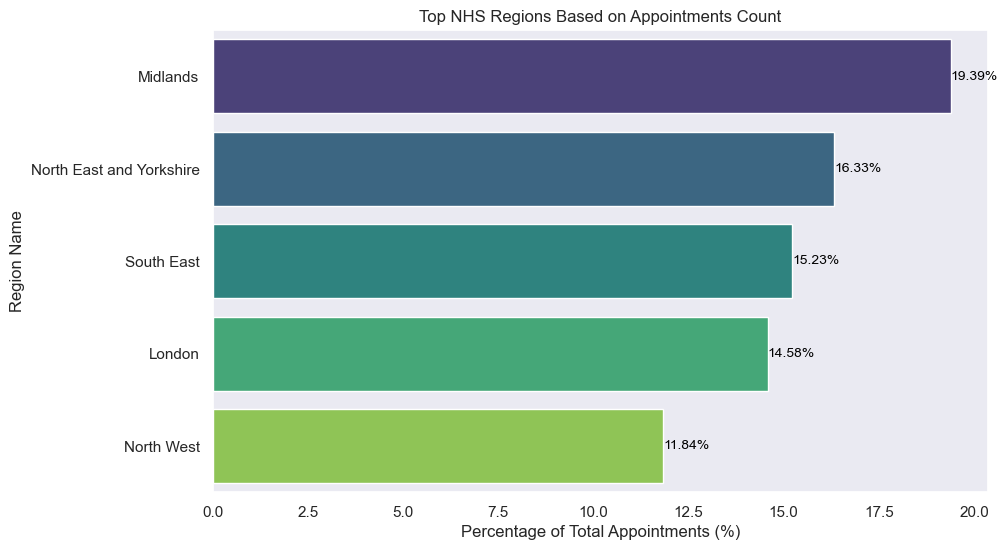

In [401]:
import matplotlib.pyplot as plt
import seaborn as sns

# Determine the top region based on appointments count in the 'ad' dataset.
top_region = ad.groupby('region_name')['count_of_appointments'].sum().nlargest(5)

# Calculate the total appointments count.
total_appointments = ad['count_of_appointments'].sum()

# Calculate the percentage for each region in the top 5.
percentage_top_region = (top_region / total_appointments) * 100

# Create a bar chart.
plt.figure(figsize=(10, 6))
sns.barplot(x=percentage_top_region.values, y=percentage_top_region.index, palette='viridis')

# Add data labels.
for i, percentage in enumerate(percentage_top_region.values):
    plt.text(percentage, i, f'{percentage:.2f}%', ha='left', va='center', fontsize=10, color='black')

# Additional styling or customization if needed
plt.xlabel('Percentage of Total Appointments (%)')
plt.ylabel('Region Name')
plt.title('Top NHS Regions Based on Appointments Count')
plt.grid(False)

plt.show()

**Question 3:** How many service settings, context types, national categories, and appointment statuses are there?

In [402]:
# Determine the number of service settings.
# Service_setting renamed as 'ss'.
ss_count = nc['service_setting'].nunique()

print("Count of service settings:", ss_count)

Count of service settings: 5


In [403]:
# Calculate the total appointments count in the 'nc' DataFrame.
total_nc = nc['count_of_appointments'].sum()

# Group by 'service_setting' and calculate the sum of 'count_of_appointments'.
ss = nc.groupby('service_setting')[['count_of_appointments']]\
.sum().sort_values('count_of_appointments', ascending=False).reset_index()\
.rename(columns={'service_setting': 'Service Setting',\
                 'count_of_appointments': 'Total Appointments'}) 

# Display the total appointments in 'nc'.
print("Total appointments in nc:", total_nc)

# Calculate the percentage of total appointments for each service setting.
ss['Percentage of Appointments'] = ss['Total Appointments'] / total_nc * 100

# Round the percentage values to one decimal place.
ss = ss.round(1)

# View the output with added percentage column.
ss

Total appointments in nc: 296046770


,Service Setting,Total Appointments,Percentage of Appointments
0,General Practice,270811691,91.5
1,Unmapped,11080810,3.7
2,Primary Care Network,6557386,2.2
3,Other,5420076,1.8
4,Extended Access Provision,2176807,0.7


<Figure size 1500x1200 with 0 Axes>

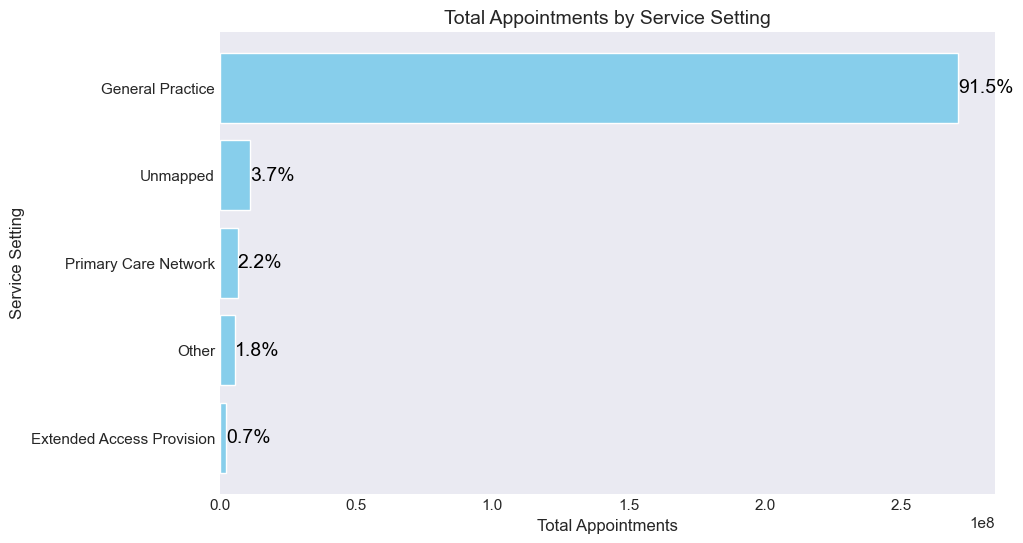

<Figure size 1000x600 with 0 Axes>

In [404]:
# Set figure size using plt.
plt.figure(figsize=(15, 12))

# Set the plot style as darkgrid.
plt.style.use('seaborn-darkgrid')

# Create a bar chart.
fig, ax = plt.subplots()
bars = ax.barh(ss['Service Setting'], ss['Total Appointments'], color='skyblue')

plt.grid(False)

# Add percentage labels.
for bar, percentage in zip(bars, ss['Percentage of Appointments']):
    ax.text(bar.get_width(), bar.get_y() + bar.get_height()/2, '{:.1f}%'.format(percentage),
            va='center', ha='left', color='black', fontsize=14)

# Set labels and title.
ax.set_xlabel('Total Appointments')
ax.set_ylabel('Service Setting')
ax.set_title('Total Appointments by Service Setting', fontsize=14)

# Invert y-axis to show highest at the top.
ax.invert_yaxis()

# View and save the plot.
plt.show()
plt.tight_layout()
plt.savefig('total_app_ss.png', dpi=96)

In [405]:
# Determine the number of context types.
# Contect_type renamed as a ct.
ct_count = nc['context_type'].nunique()

print("Count of context type:", ct_count)

Count of context type: 3


In [406]:
# Group by 'context_type' and calculate the sum of 'count_of_appointments'.
ct = nc.groupby('context_type')[['count_of_appointments']].sum()\
    .sort_values('count_of_appointments', ascending=False)\
    .reset_index()\
    .rename(columns={'context_type': 'Context Type', 'count_of_appointments': 'Total Appointments'}) 

# Calculate the percentage of total appointments for each context type.
ct['Percentage of Appointments'] = ct['Total Appointments'] / total_nc * 100

# Round the percentage values to one decimal place.
ct = ct.round(1)

# View the output with added percentage columns.
ct

,Context Type,Total Appointments,Percentage of Appointments
0,Care Related Encounter,257075158,86.8
1,Inconsistent Mapping,27890802,9.4
2,Unmapped,11080810,3.7


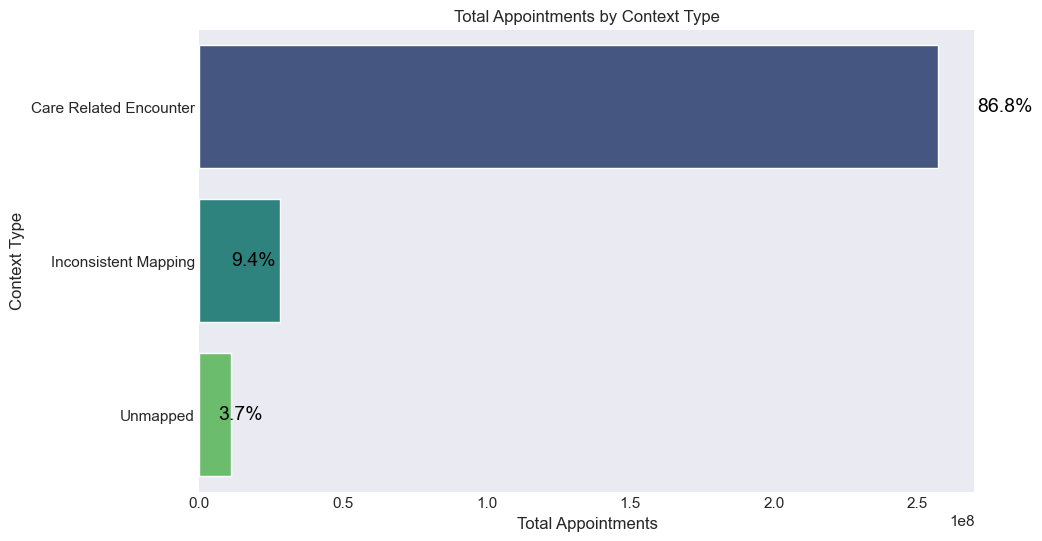

<Figure size 1000x600 with 0 Axes>

In [407]:
# Create a bar chart.
plt.figure(figsize=(10,6))
sns.barplot(x='Total Appointments', y='Context Type', data=ct, palette='viridis')

plt.grid(False)

# Add bar labels with the percentage of total appointments.
for bar, percentage in zip(ax.patches, ct['Percentage of Appointments']):
    plt.text(bar.get_width(), bar.get_y() + bar.get_height()/2, f'{percentage}%', 
             va='center', ha='left', color='black', fontsize=14)
    
# Set labels and title.
plt.xlabel('Total Appointments')
plt.ylabel('Context Type')
plt.title('Total Appointments by Context Type', fontsize=12)

# View and save the plot.
plt.show()
plt.tight_layout()
plt.savefig('total_app_ct', dpi=96)

In [408]:
# Determine the number of national categories.
# The national categories named as 'nc_count'.
nc_count = len(nc['national_category'].value_counts())

print("Count of appointment status:", nc_count)

Count of appointment status: 18


In [409]:
# Group by 'national_category' and calculate the sum of 'count_of_appointments'.
nc_count = nc.groupby('national_category')[['count_of_appointments']].sum()\
    .sort_values('count_of_appointments', ascending=False)\
    .reset_index()\
    .rename(columns={'national_category': 'National Category', 'count_of_appointments': 'Total Appointments'}) 

# Calculate the percentage of total appointments for each national_category.
nc_count['Percentage of Appointments'] = nc_count['Total Appointments'] / total_nc * 100

# Round the percentage values to one decimal place.
nc_count = nc_count.round(1)

# View the output with added percentage columns.
nc_count

,National Category,Total Appointments,Percentage of Appointments
0,General Consultation Routine,97271522,32.9
1,General Consultation Acute,53691150,18.1
2,Clinical Triage,41546964,14.0
3,Planned Clinics,28019748,9.5
4,Inconsistent Mapping,27890802,9.4
5,Planned Clinical Procedure,25702694,8.7
6,Unmapped,11080810,3.7
7,Unplanned Clinical Activity,3055794,1.0
8,Home Visit,2144452,0.7
9,Structured Medication Review,1858379,0.6


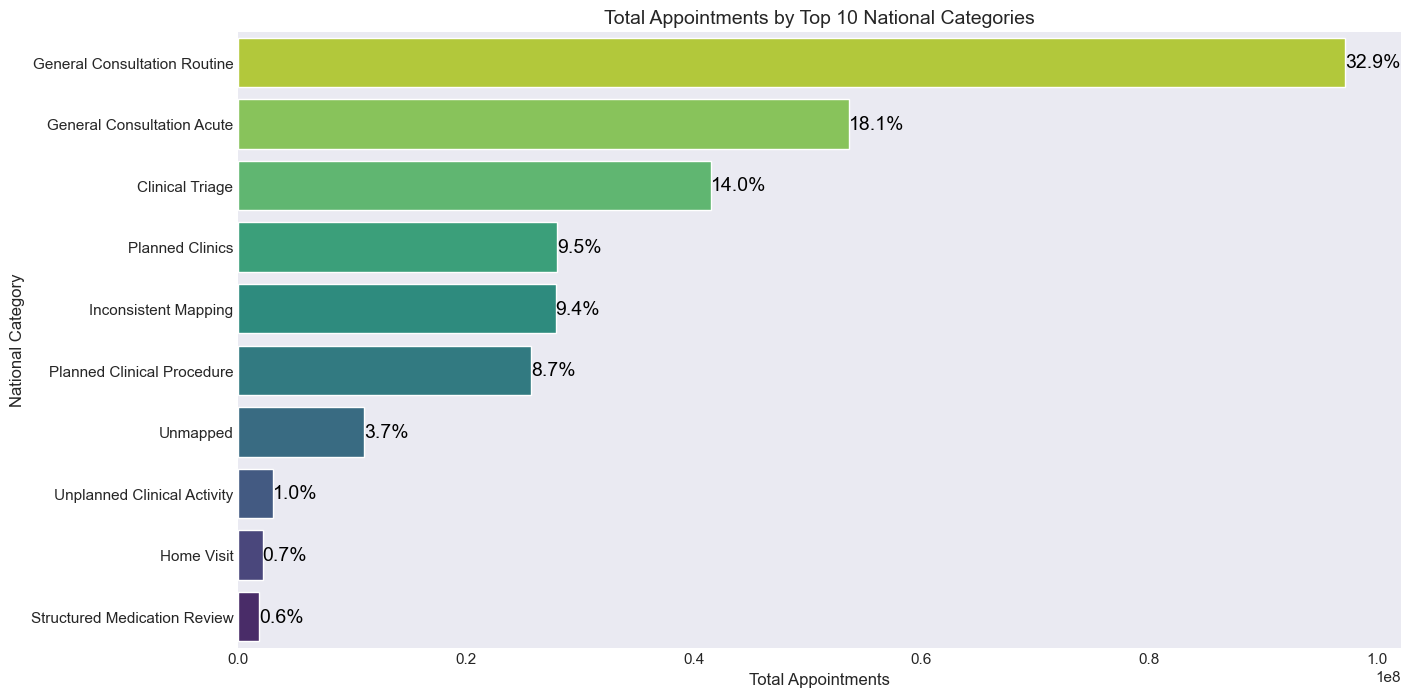

<Figure size 1000x600 with 0 Axes>

In [410]:
# Set the plot style as darkgrid.
sns.set_style('darkgrid')

# Sort the dataframe by 'Total Appointments' in descending order and select the top 10.
top_ten_nc_count = nc_count.sort_values('Total Appointments', ascending=False).head(10)

# Create a horizontal bar chart using Seaborn.
plt.figure(figsize=(15, 8))
ax = sns.barplot(x='Total Appointments', y='National Category', data=top_ten_nc_count, palette='viridis_r')

# Remove grid lines.
ax.grid(False)

# Add percentage labels.
for bar, percentage in zip(ax.patches, top_ten_nc_count['Percentage of Appointments']):
    plt.text(bar.get_width(), bar.get_y() + bar.get_height()/2, '{:.1f}%'.format(percentage),
             va='center', ha='left', color='black', fontsize=14)

# Set labels and title.
plt.xlabel('Total Appointments')
plt.ylabel('National Category')
plt.title('Total Appointments by Top 10 National Categories', fontsize=14)

# View and save the plot.
plt.show()
plt.tight_layout()
plt.savefig('total_app_nc.png', dpi=96)

In [411]:
# Determine the number of appointment statuses.
# The appointment statuses named as 'as_count'.
as_count = len(ar_cleaned['appointment_status'].value_counts())

print("Count of appointment status:", as_count)

Count of appointment status: 3


In [412]:
# Group by 'appointment_status' and calculate the sum of 'count_of_appointments'.
as_count = ar_cleaned.groupby('appointment_status')[['count_of_appointments']].sum()\
    .sort_values('count_of_appointments', ascending=False)\
    .reset_index()\

# Calculate the total appointments count.
total_as_count = ar_cleaned['count_of_appointments'].sum()

# Calculate the percentage of total appointments for each appointment_status.
as_count['percentage_of_appointments'] = as_count['count_of_appointments'] / total_as_count * 100

# Round the percentage values to one decimal place.
as_count = as_count.round(1)

# View the output with added percentage columns.
as_count

,appointment_status,count_of_appointments,percentage_of_appointments
0,Attended,677646088,91.3
1,Unknown,34050656,4.6
2,DNA,30833015,4.2


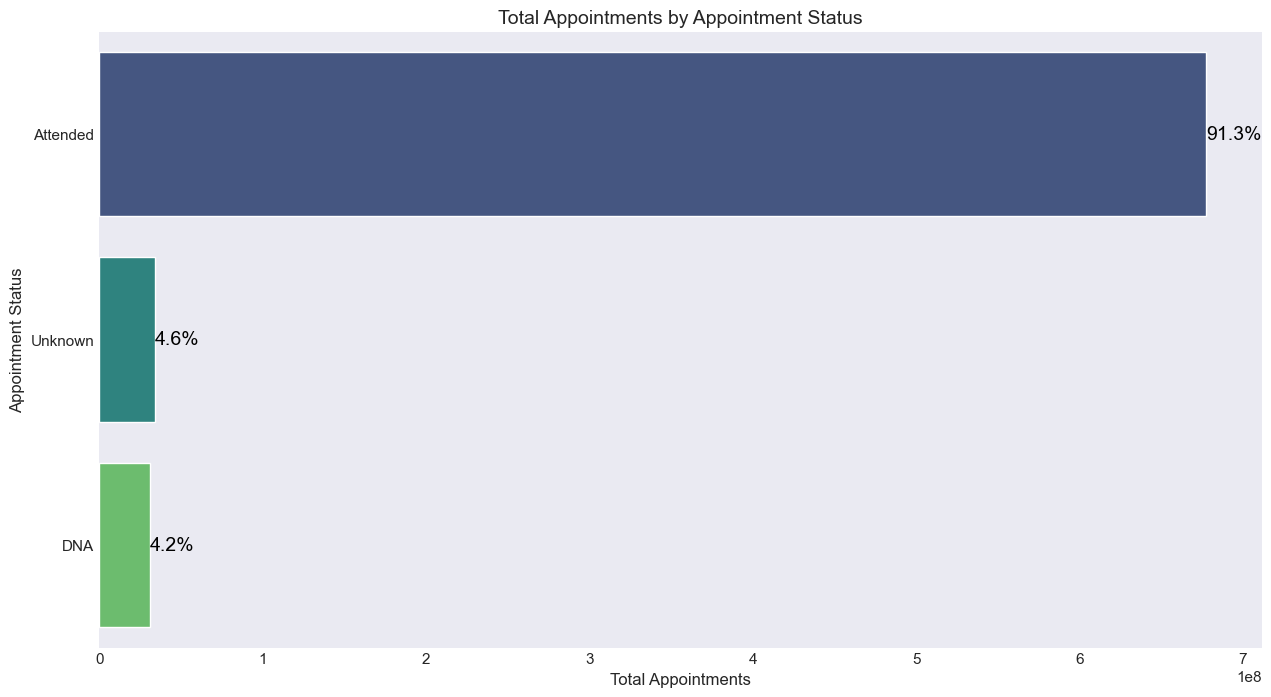

<Figure size 1000x600 with 0 Axes>

In [413]:
# Create a horizontal bar chart using Seaborn.
plt.figure(figsize=(15, 8))
ax = sns.barplot(x='count_of_appointments', y='appointment_status', data=as_count, palette='viridis')

# Remove grid lines.
ax.grid(False)

# Add percentage labels.
for bar, percentage in zip(ax.patches, as_count['percentage_of_appointments']):
    plt.text(bar.get_width(), bar.get_y() + bar.get_height()/2, '{:.1f}%'.format(percentage),
             va='center', ha='left', color='black', fontsize=14)

# Set labels and title.
plt.xlabel('Total Appointments')
plt.ylabel('Appointment Status')
plt.title('Total Appointments by Appointment Status', fontsize=14)

# View and save the plot.
plt.show()
plt.tight_layout()
plt.savefig('total_app_ap.png', dpi=96)

### Further Exploration 

**Question 4:** How many appointment mode and healthcare professional type are there?

In [414]:
# Checking column names in ar_cleaned.
ar_cleaned.columns

Index(['icb_ons_code', 'appointment_month', 'appointment_status', 'hcp_type',
       'appointment_mode', 'time_between_book_and_appointment',
       'count_of_appointments'],
      dtype='object')

In [415]:
# Determine the number of appointment_mode.
# The appointment_mode named as 'am'.
am_count = len(ar_cleaned['appointment_mode'].value_counts())

print("Count of appointment status:", am_count)

Count of appointment status: 5


In [416]:
# Group by 'appointment_mode' and calculate the sum of 'count_of_appointments'.
am = ar_cleaned.groupby('appointment_mode')[['count_of_appointments']].sum()\
    .sort_values('count_of_appointments', ascending=False)\
    .reset_index()
   
# Calculate the total appointments count.
total_am_count = ar_cleaned['count_of_appointments'].sum()

# Calculate the percentage of total appointments for each appointment mode.
am['percentage_of_appointments'] = am['count_of_appointments'] / total_am_count * 100

# Round the percentage values to one decimal place.
am = am.round(1)

# View the output with added percentage columns.
am

,appointment_mode,count_of_appointments,percentage_of_appointments
0,Face-to-Face,439876928,59.2
1,Telephone,267752505,36.1
2,Unknown,26439308,3.6
3,Home Visit,4848743,0.7
4,Video/Online,3612275,0.5


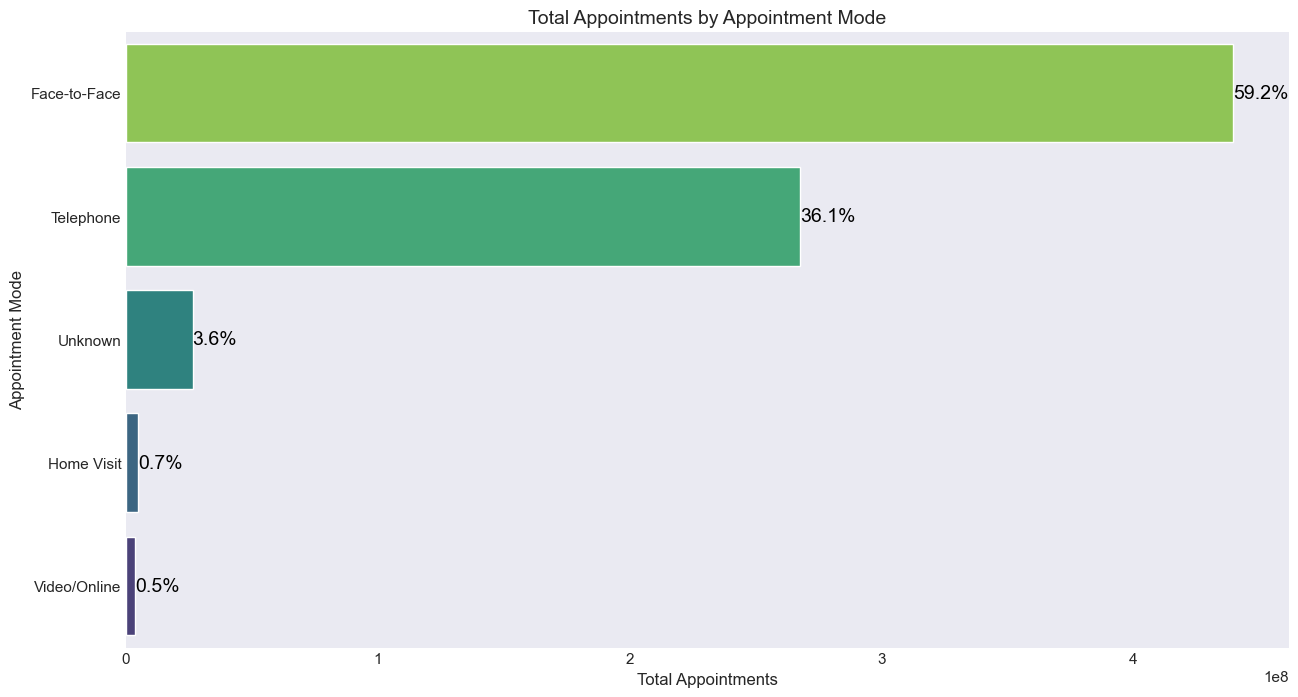

<Figure size 1000x600 with 0 Axes>

In [417]:
# Create a bar chart using Seaborn.
plt.figure(figsize=(15, 8))
ax = sns.barplot(x='count_of_appointments', y='appointment_mode', data=am, palette='viridis_r')

# Remove grid lines.
ax.grid(False)

# Add percentage labels.
for bar, percentage in zip(ax.patches, am['percentage_of_appointments']):
    plt.text(bar.get_width(), bar.get_y() + bar.get_height()/2, '{:.1f}%'.format(percentage),
             va='center', ha='left', color='black', fontsize=14)

# Set labels and title.
plt.xlabel('Total Appointments')
plt.ylabel('Appointment Mode')
plt.title('Total Appointments by Appointment Mode', fontsize=14)

# View and save the plot.
plt.show()
plt.tight_layout()
plt.savefig('total_app_am.png', dpi=96)

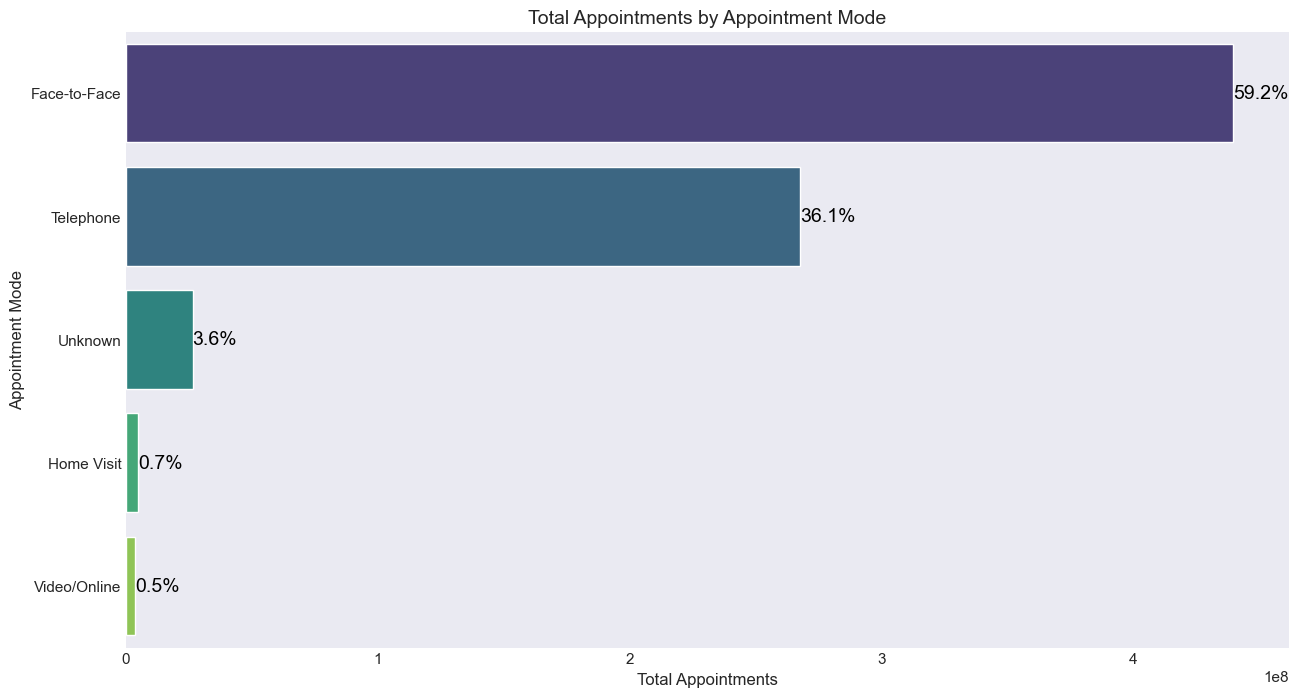

<Figure size 1000x600 with 0 Axes>

In [418]:
# Sort the dataframe by 'Total Appointments' in descending order.
am = am.sort_values('count_of_appointments', ascending=False)

# Create a horizontal bar chart using Seaborn.
plt.figure(figsize=(15, 8))
ax = sns.barplot(x='count_of_appointments', y='appointment_mode', data=am, palette='viridis')

# Remove grid lines.
ax.grid(False)

# Add percentage labels.
for bar, percentage in zip(ax.patches, am['percentage_of_appointments']):
    plt.text(bar.get_width(), bar.get_y() + bar.get_height()/2, '{:.1f}%'.format(percentage),
             va='center', ha='left', color='black', fontsize=14)

# Set labels and title.
plt.xlabel('Total Appointments')
plt.ylabel('Appointment Mode')
plt.title('Total Appointments by Appointment Mode', fontsize=14)

# View and save the plot.
plt.show()
plt.tight_layout()
plt.savefig('total_app_ap.png', dpi=96)

In [419]:
# Determine the number of healthcare professional type.
hcp_count = len(ar_cleaned['hcp_type'].value_counts())

print("Count of appointment status:", hcp_count)

Count of appointment status: 3


In [420]:
# Group by 'hcp_type' and calculate the sum of 'count_of_appointments'.
# The healthcare professional type named as 'hcp_type'.
hcp_type = ar_cleaned.groupby('hcp_type')[['count_of_appointments']].sum() \
    .sort_values('count_of_appointments', ascending=False) \
    .reset_index() 

# Calculate the total appointments count.
total_hcp_type_count = ar_cleaned['count_of_appointments'].sum()

# Calculate the percentage of total appointments for each healthcare professional type.
hcp_type['percentage_of_appointments'] = (hcp_type['count_of_appointments'] / total_hcp_type_count) * 100

# Round the percentage values to one decimal place.
hcp_type = hcp_type.round(1)

# View the output with added percentage columns.
hcp_type

,hcp_type,count_of_appointments,percentage_of_appointments
0,GP,379532056,51.1
1,Other Practice staff,339528981,45.7
2,Unknown,23468722,3.2


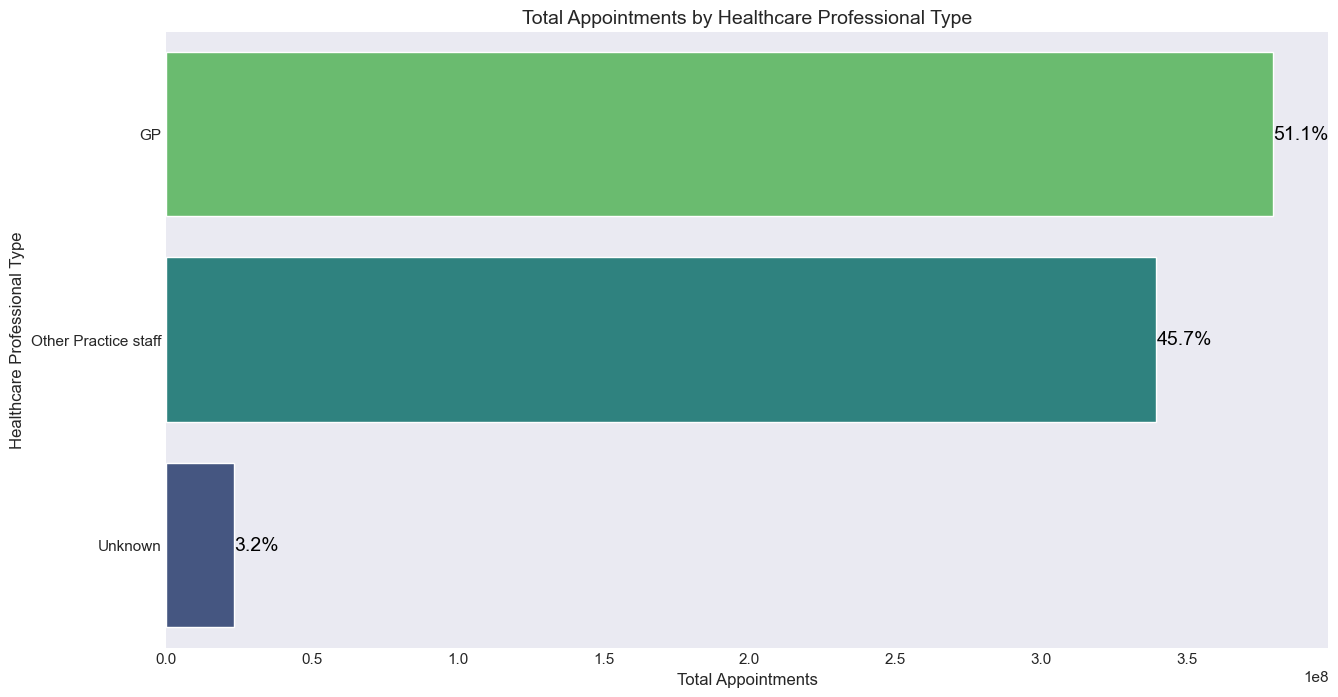

<Figure size 1000x600 with 0 Axes>

In [421]:
# Create a bar chart using Seaborn.
plt.figure(figsize=(15, 8))
ax = sns.barplot(x='count_of_appointments', y='hcp_type', data=hcp_type, palette='viridis_r')

# Remove grid lines.
ax.grid(False)

# Add percentage labels.
for bar, percentage in zip(ax.patches, hcp_type['percentage_of_appointments']):
    plt.text(bar.get_width(), bar.get_y() + bar.get_height()/2, '{:.1f}%'.format(percentage),
             va='center', ha='left', color='black', fontsize=14)

# Set labels and title.
plt.xlabel('Total Appointments')
plt.ylabel('Healthcare Professional Type')
plt.title('Total Appointments by Healthcare Professional Type', fontsize=14)

# View and save the plot.
plt.show()
plt.tight_layout()
plt.savefig('total_app_hcp_type.png', dpi=96)

> ### Key Findings 

**1. Exploration of NHS locations:**

- The dataset includes information from 106 sub_icb locations, 7 regions and 42 icb locations.

- The top 5 sub ICB locations are NHS North West London, NHS Kent and Medway, NHS Devon ICB, NHS Hampshire and Isle Of Wight, and NHS North East London.

- The top ICB location is NHS North East and North Cumbria. 

- The top region is Midlands by 19.39%.

**2. Exploration in nc dataset:**

- Total appointments are 296046770.

- This dataset consists of 5 distinct service settings, with General Practice notably standing out as a significant setting, contributing to a substantial portion, specifically 91.5% of the total appointments.

- This dataset consists of 3 context types with Care Related Encounter, representing a substantial majority at 86.8%.
 
- This dataset consists of 18 national categories and General Consultation Routine, representing 32.9% of the total appointments.

**3. Exploration in ar_cleaned dataset:**

- In this dataset, the majority, 91.3%, attended appointments, and only 4.2% did not attend.

- The distribution of appointment modes, with "Face-to-Face" appointments representing 59.2% of the total, while "Telephone" appointments make up 36.1%.

- Among healthcare professionals, General Practitioners (GPs) account for 51.1% of total appointments, while Other Practice staff make up 45.7%.

## 3) Assignment activity 3

### Continue to explore the data and search for answers to more specific questions posed by the NHS.

**Question 1:** Between what dates were appointments scheduled? 

In [422]:
# View the first five rows of appointment_date for the ad DataFrame to determine the date format.
print(ad['appointment_date'].head())

0    01-Dec-21
1    01-Dec-21
2    01-Dec-21
3    01-Dec-21
4    01-Dec-21
Name: appointment_date, dtype: object


In [423]:
print(nc.columns)

Index(['appointment_date', 'icb_ons_code', 'sub_icb_location_name',
       'service_setting', 'context_type', 'national_category',
       'count_of_appointments', 'appointment_month'],
      dtype='object')


In [424]:
# View the first five rows of appointment_date for the nc DataFrame to determine the date format.
print(nc['appointment_date'].head())

0   2021-08-02
1   2021-08-02
2   2021-08-02
3   2021-08-02
4   2021-08-02
Name: appointment_date, dtype: datetime64[ns]


In [425]:
# Change the date format of ad['appointment_date'].
ad['appointment_date'] = pd.to_datetime(ad['appointment_date'])

# View the DataFrame.
ad['appointment_date'].head()

0   2021-12-01
1   2021-12-01
2   2021-12-01
3   2021-12-01
4   2021-12-01
Name: appointment_date, dtype: datetime64[ns]

**Changing the data type to datetime simplifies working with dates compared to using strings, making it easier to analyze and manipulate date-related information.**

In [426]:
# Determine the minimum and maximum dates in the ad DataFrame.
min_date = ad['appointment_date'].min().date()
max_date = ad['appointment_date'].max().date()

print("The first appointment date:", min_date)
print("The last appointment date:", max_date)

The first appointment date: 2021-12-01
The last appointment date: 2022-06-30


In [427]:
# Determine the minimum and maximum dates in the nc DataFrame.
min_date = nc['appointment_date'].min().date()
max_date = nc['appointment_date'].max().date()

print("The first appointment date:", min_date)
print("The last appointment date:", max_date)

The first appointment date: 2021-08-01
The last appointment date: 2022-06-30


**Question 2:** Which service setting was the most popular for NHS North West London from 1 January to 1 June 2022?

In [428]:
# For each of these service settings, determine the number of records available for the period and the location.
# Create a subset of the nc DataFrame
nc_subset = nc.loc[(nc['sub_icb_location_name'] == 'NHS North West London ICB - W2U3Z') & 
                   (nc['appointment_date'].between('2022-01-01', '2022-06-01'))]

# View the output.
nc_subset

,appointment_date,icb_ons_code,sub_icb_location_name,service_setting,context_type,national_category,count_of_appointments,appointment_month
800289,2022-01-01,E54000027,NHS North West London ICB - W2U3Z,Unmapped,Unmapped,Unmapped,496,2022-01
800290,2022-01-01,E54000027,NHS North West London ICB - W2U3Z,Primary Care Network,Care Related Encounter,Clinical Triage,19,2022-01
800291,2022-01-01,E54000027,NHS North West London ICB - W2U3Z,Other,Inconsistent Mapping,Inconsistent Mapping,1,2022-01
800292,2022-01-01,E54000027,NHS North West London ICB - W2U3Z,General Practice,Inconsistent Mapping,Inconsistent Mapping,16,2022-01
800293,2022-01-01,E54000027,NHS North West London ICB - W2U3Z,Primary Care Network,Care Related Encounter,Planned Clinics,29,2022-01
...,...,...,...,...,...,...,...,...
806220,2022-06-01,E54000027,NHS North West London ICB - W2U3Z,Extended Access Provision,Care Related Encounter,Home Visit,4,2022-06
806221,2022-06-01,E54000027,NHS North West London ICB - W2U3Z,Extended Access Provision,Care Related Encounter,General Consultation Routine,27,2022-06
806222,2022-06-01,E54000027,NHS North West London ICB - W2U3Z,General Practice,Care Related Encounter,Unplanned Clinical Activity,626,2022-06
806223,2022-06-01,E54000027,NHS North West London ICB - W2U3Z,Extended Access Provision,Care Related Encounter,General Consultation Acute,224,2022-06


In [429]:
# Group by service setting and calculate the percentage of appointments.
percentage_appointments = (nc_subset.groupby('service_setting')['count_of_appointments'].sum() / 
                           nc_subset['count_of_appointments'].sum() * 100).round(1)

# Sort the results by the count of appointments in descending order.
ss_appointments = percentage_appointments.sort_values(ascending=False)

# Find the most popular service setting.
most_popular_ss = ss_appointments.idxmax()

print("The most popular service setting for NHS North West London from 1 January to 1 June 2022 was:", most_popular_ss)

# Display the sorted percentage of appointments for each service setting.
print("\nPercentage of appointments for each service setting:")
print(ss_appointments)

The most popular service setting for NHS North West London from 1 January to 1 June 2022 was: General Practice

Percentage of appointments for each service setting:
service_setting
General Practice             86.5
Unmapped                      7.0
Other                         2.8
Primary Care Network          2.0
Extended Access Provision     1.8
Name: count_of_appointments, dtype: float64


In [430]:
# Determine the number of unique service settings
num_ss = nc_subset['service_setting'].nunique()
num_ss

5

In [431]:
# Calculate total number of appointments per service setting and sort in descending order.
nc_ss_count = nc_subset.groupby('service_setting')['count_of_appointments'].sum()\
.sort_values(ascending=False)

print("Total number of appointments per service setting:")
print(nc_ss_count)

Total number of appointments per service setting:
service_setting
General Practice             4804239
Unmapped                      391106
Other                         152897
Primary Care Network          109840
Extended Access Provision      98159
Name: count_of_appointments, dtype: int64


**Question 3:** Which month had the highest number of appointments?

In [432]:
# Number of appointments per month == sum of count_of_appointments by month.
# Use the groupby() and sort_values() functions.

# Group by month and sum the count_of_appointments.
appointments_per_month = nc.groupby(nc['appointment_date'].dt.to_period("M"))\
['count_of_appointments'].sum()

# Sort the result by the highest number of appointments in descending order.
appointments_per_month = appointments_per_month.sort_values(ascending=False)

# View the output.
print("Number of appointments per month (sorted by highest):")
print(appointments_per_month)

Number of appointments per month (sorted by highest):
appointment_date
2021-11    30405070
2021-10    30303834
2022-03    29595038
2021-09    28522501
2022-05    27495508
2022-06    25828078
2022-01    25635474
2022-02    25355260
2021-12    25140776
2022-04    23913060
2021-08    23852171
Freq: M, Name: count_of_appointments, dtype: int64


In [433]:
# Find the top 5 months with the highest number of appointments.
top_5_appointments_months = appointments_per_month.sort_values(ascending=False).head(5)

# View the output.
print("Top 5 months with the highest number of appointments:")
print(top_5_appointments_months)

Top 5 months with the highest number of appointments:
appointment_date
2021-11    30405070
2021-10    30303834
2022-03    29595038
2021-09    28522501
2022-05    27495508
Freq: M, Name: count_of_appointments, dtype: int64


In [434]:
nc.columns

Index(['appointment_date', 'icb_ons_code', 'sub_icb_location_name',
       'service_setting', 'context_type', 'national_category',
       'count_of_appointments', 'appointment_month'],
      dtype='object')

In [435]:
# Convert the timestamp to a datetime object.
nc['appointment_month'] = pd.to_datetime(nc['appointment_month'])

# Extract the day of the week and create a new column.
nc['day_of_week'] = nc['appointment_month'].dt.day_name()

# Create the new DataFrame by grouping.
nc_app = nc.groupby(['appointment_month', 'day_of_week'])['count_of_appointments'].sum().reset_index()

# Display the first few rows of the new DataFrame.
print(nc_app.head())

  appointment_month day_of_week  count_of_appointments
0        2021-08-01      Sunday               23852171
1        2021-09-01   Wednesday               28522501
2        2021-10-01      Friday               30303834
3        2021-11-01      Monday               30405070
4        2021-12-01   Wednesday               25140776


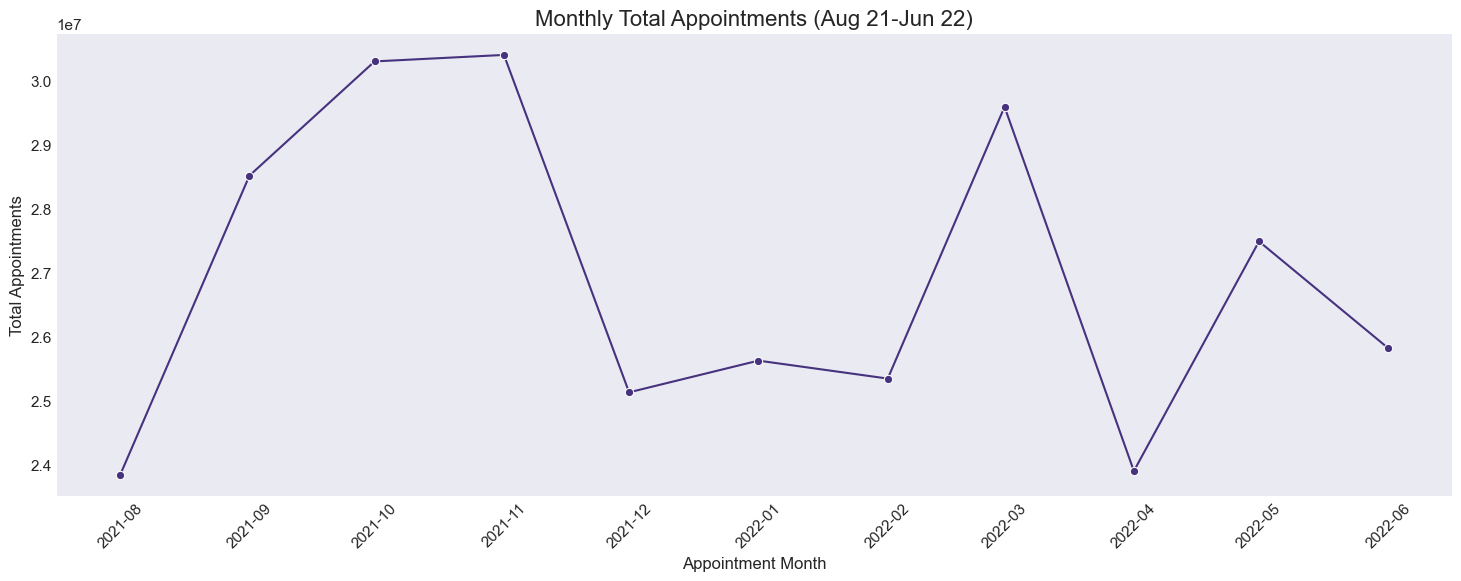

<Figure size 1000x600 with 0 Axes>

In [436]:
# Create a line plot for changes in appointment mode over time.
plt.figure(figsize=(18, 6))
sns.lineplot(x='appointment_month', y='count_of_appointments', data=nc_app, marker='o', palette='viridis')

# Set labels and title.
plt.xlabel('Appointment Month')
plt.ylabel('Total Appointments')
plt.title('Monthly Total Appointments (Aug 21-Jun 22)', fontsize=16)
plt.xticks(rotation=45)

# Turn off grid lines.
plt.grid(False)

# Show and save the plot.
plt.show()
plt.savefig('nc_totalapp_monthly', dpi=96)

**Question 4:** What was the total number of records per month?

In [437]:
# Total number of records per month for nc data source.
nc.groupby([nc['appointment_date'].dt.year,
          nc['appointment_date'].dt.month]).size().sort_values(ascending=False)

appointment_date  appointment_date
2022              3                   82822
2021              11                  77652
2022              5                   77425
2021              9                   74922
2022              6                   74168
2021              10                  74078
                  12                  72651
2022              1                   71896
                  2                   71769
                  4                   70012
2021              8                   69999
dtype: int64

In [438]:
# Total number of records per month for ad data source.
nc.groupby([ad['appointment_date'].dt.year,
                     ad['appointment_date'].dt.month]).size().sort_values(ascending=False)

appointment_date  appointment_date
2022.0            3.0                 21236
                  5.0                 20128
                  1.0                 19643
2021.0            12.0                19507
2022.0            6.0                 19227
                  4.0                 19078
                  2.0                 18974
dtype: int64

> ### Key Findings:

**1.	Appointment Schedule Periods:**
- ‘ad’: appointments were scheduled between 1st December 2021 and 30th June 2022, while in the ‘nc’ data set: appointments were scheduled between 1st August 2021 and 30th June 2022.

**2. Most Popular Service Setting:**
- General Practice emerged as the most popular service setting, constituting a 86.46% of total appointments amongst the five settings in NHS North West London (1st January - 1st June 2022).

**3. Top 3 Months with Highest Appointments:**
- November 2021 had the highest number of appointments, totalling 30,405,070.
- October 2021 closely followed with 30,303,834 appointments.
- March 2022 secured the third position with 29,595,038 appointments.

(October and November are in the season of autumn, while March marks the beginning of spring).

**4. Total Number of Records per Month:**
- March 2022 recorded the highest number of records in both datasets: 82,822 records in the 'nc' dataset and 21,236 records in the 'ad' dataset.

## 4) Assignment activity 4

The seasons are summer (June to August 2021), autumn (September to November 2021), winter (December to February 2022), and spring (March to May 2022).

### Create visualisations and identify possible monthly and seasonal trends in the data.

In [439]:
# Set figure size.
sns.set(rc={'figure.figsize':(15, 12)})

# Set the plot style as darkgrid.
sns.set_style('darkgrid')

### Objective 1
Create isualisations indicating the number of appointments per month for service settings, context types, and national categories.

In [440]:
# Change the data type of the appointment month to string to allow for easier plotting.
nc['appointment_month'] = nc['appointment_month'].astype(str)

nc.dtypes

appointment_date         datetime64[ns]
icb_ons_code                     object
sub_icb_location_name            object
service_setting                  object
context_type                     object
national_category                object
count_of_appointments             int64
appointment_month                object
day_of_week                      object
dtype: object

In [441]:
# Aggregate on a monthly level and determine the sum of records per month.
nc_mnt = nc.groupby('appointment_month').size().reset_index(name='count_of_appointments')
output = nc_mnt.sort_values('count_of_appointments', ascending=False)

# View the output.
print(output)

   appointment_month  count_of_appointments
7         2022-03-01                  82822
3         2021-11-01                  77652
9         2022-05-01                  77425
1         2021-09-01                  74922
10        2022-06-01                  74168
2         2021-10-01                  74078
4         2021-12-01                  72651
5         2022-01-01                  71896
6         2022-02-01                  71769
8         2022-04-01                  70012
0         2021-08-01                  69999


**Service settings:**

In [442]:
# Display the column names in your DataFrame
print(nc.columns)

Index(['appointment_date', 'icb_ons_code', 'sub_icb_location_name',
       'service_setting', 'context_type', 'national_category',
       'count_of_appointments', 'appointment_month', 'day_of_week'],
      dtype='object')


In [443]:
# Create a separate data set that can be used in future weeks.
nc_ss = nc[['service_setting', 'count_of_appointments', 'appointment_month']]
nc_ss = nc_ss.groupby(['appointment_month', 'service_setting']).sum('count_of_appointments').reset_index()

# View the output.
nc_ss.head()

,appointment_month,service_setting,count_of_appointments
0,2021-08-01,Extended Access Provision,160927
1,2021-08-01,General Practice,21575852
2,2021-08-01,Other,449101
3,2021-08-01,Primary Care Network,432448
4,2021-08-01,Unmapped,1233843


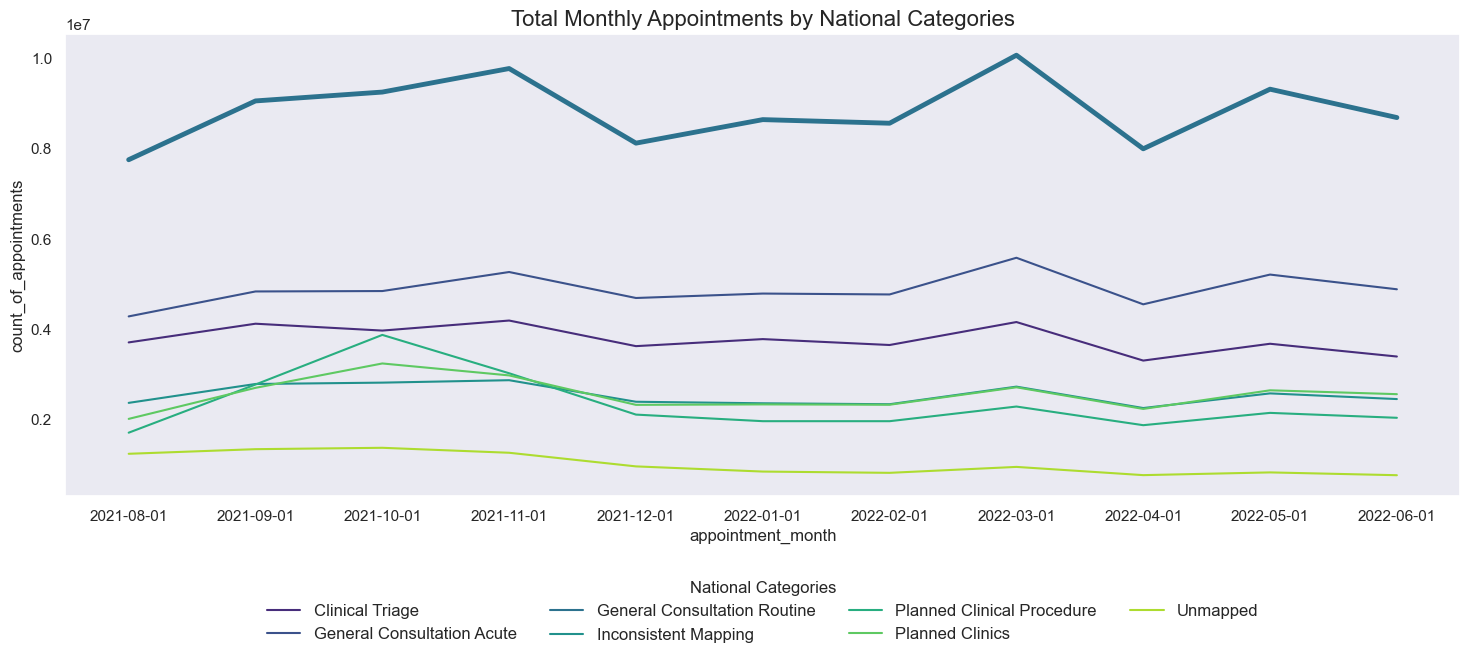

In [508]:
# Create a line plot using the filtered data.
plt.figure(figsize=(18, 6))

# Create a line plot using the filtered data.
ax = sns.lineplot(x='appointment_month', y='count_of_appointments', hue='national_category',
                   data=filtered_nc_nc,
                   palette='viridis')

# Turn off grid lines.
ax.grid(False)

plt.title('Total Monthly Appointments by National Categories', fontsize=16)

# Make the line for "Care Related Encounter" thicker.
care_related_encounter_line = ax.lines[2]
care_related_encounter_line.set_linewidth(3.5)

# Change legend title and size and move it to the bottom.
ax.legend(title='National Categories', bbox_to_anchor=(0.5, -0.15), loc='upper center', ncol=4, fontsize='medium')

# Show the plot.
plt.show()

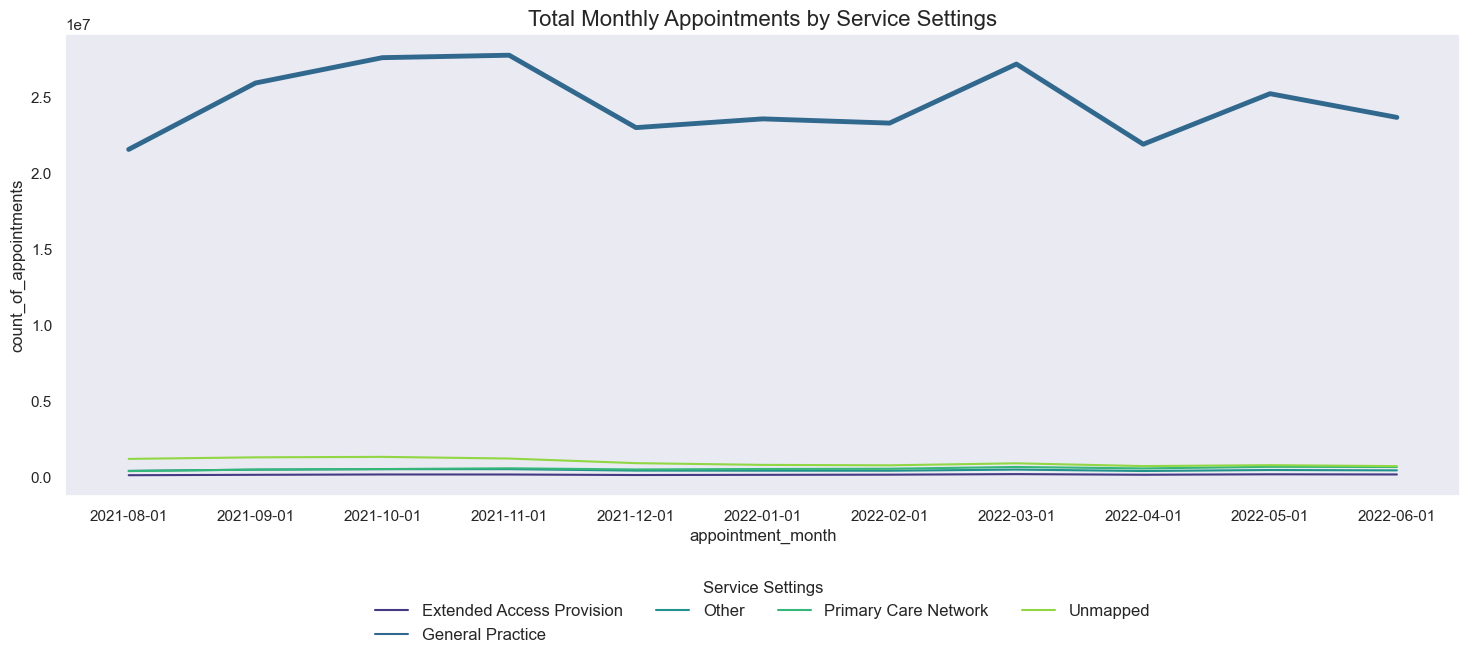

<Figure size 1000x600 with 0 Axes>

In [509]:
# Plot the appointments over the available date range, and review the service settings for months.
plt.figure(figsize=(18, 6))
ax = sns.lineplot(x='appointment_month', y='count_of_appointments', hue='service_setting', data=nc_ss, palette='viridis')

# Turn off grid lines.
ax.grid(False)

plt.title('Total Monthly Appointments by Service Settings', fontsize=16)

# Make the line for "General Practice" thicker.
general_practice_line = ax.lines[1]  
general_practice_line.set_linewidth(3.5)  

# Change legend title and size and move it to the bottom.
ax.legend(title='Service Settings', bbox_to_anchor=(0.5, -0.15), loc='upper center', ncol=4, fontsize='medium')

# View and save the plot.
plt.show()
plt.savefig('total_monthly_app_ss.png', dpi=96)

<function matplotlib.pyplot.show(close=None, block=None)>

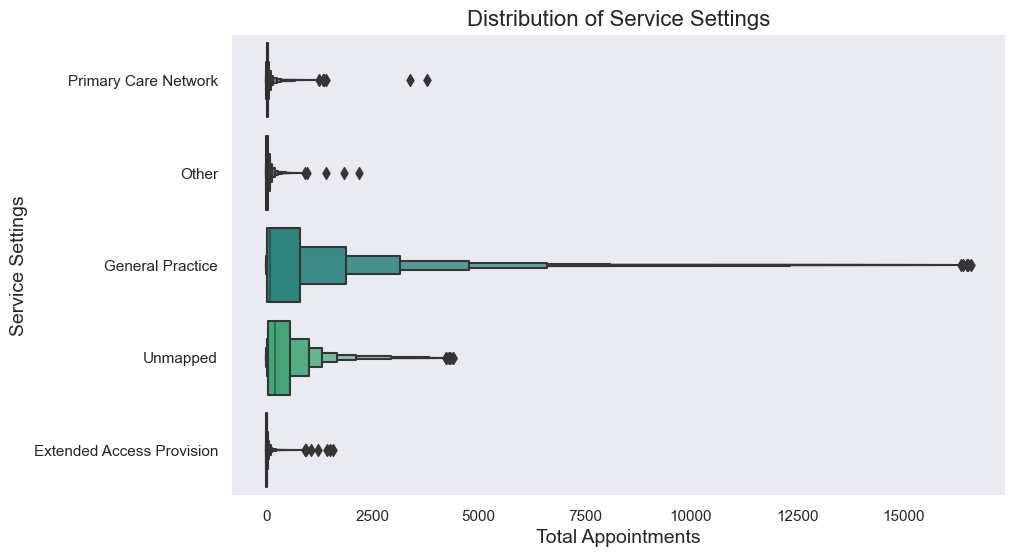

In [510]:
#Visualise the distribution of service settings.
sns.boxenplot(x="count_of_appointments", y="service_setting", data=nc,  palette='viridis')
plt.title("Distribution of Service Settings", fontsize=16)
plt.xlabel("Total Appointments", fontsize=14)
plt.ylabel("Service Settings", fontsize=14)
plt.grid(False)

plt.show

**Context types:**

In [447]:
# Create a separate data set that can be used in future weeks.
nc_ct = nc[['context_type', 'count_of_appointments', 'appointment_month']]
nc_ct = nc_ct.groupby(['appointment_month', 'context_type']).sum('count_of_appointments').reset_index()

# View the output.
nc_ct.head()

,appointment_month,context_type,count_of_appointments
0,2021-08-01,Care Related Encounter,20255235
1,2021-08-01,Inconsistent Mapping,2363093
2,2021-08-01,Unmapped,1233843
3,2021-09-01,Care Related Encounter,24404251
4,2021-09-01,Inconsistent Mapping,2782135


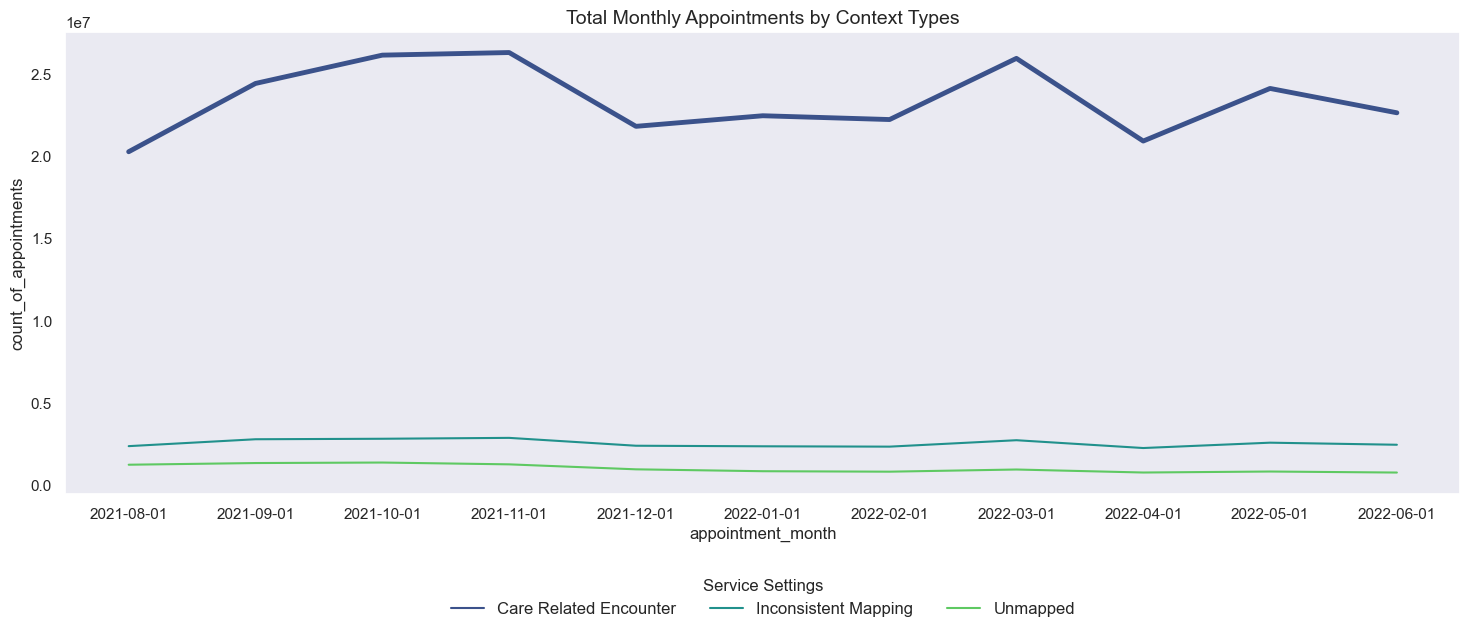

<Figure size 1500x1200 with 0 Axes>

In [448]:
# Plot the appointments over the available date range, and review the context types for months.
# Create a lineplot.
plt.figure(figsize=(18, 6))
ax1 = sns.lineplot(x='appointment_month', y='count_of_appointments', hue='context_type', 
                   data=nc_ct, 
                   palette='viridis')

# Turn off grid lines.
ax1.grid(False)

# Set the title for the plot.
plt.title('Total Monthly Appointments by Context Types', fontsize=14)

# Make the line for "Care Related Encounter" thicker.
care_related_encounter_line = ax1.lines[0]  
care_related_encounter_line.set_linewidth(3.5) 

# Change legend title and size and move it to the bottom.
ax1.legend(title='Service Settings', bbox_to_anchor=(0.5, -0.15), loc='upper center', ncol=4, fontsize='medium')

plt.show()
plt.savefig('total_monthly_app_ct.png', dpi=96)

**National categories:**

In [449]:
# Create a separate data set that can be used in future weeks. 
nc_nc = nc[['national_category', 'count_of_appointments', 'appointment_month']]
nc_nc = nc_nc.groupby(['appointment_month', 'national_category']).sum('count_of_appointments').reset_index()

# View the output.
nc_nc.head()

,appointment_month,national_category,count_of_appointments
0,2021-08-01,Care Home Needs Assessment & Personalised Care and Support Planning,29676
1,2021-08-01,Care Home Visit,47583
2,2021-08-01,Clinical Triage,3704207
3,2021-08-01,General Consultation Acute,4280920
4,2021-08-01,General Consultation Routine,7756045


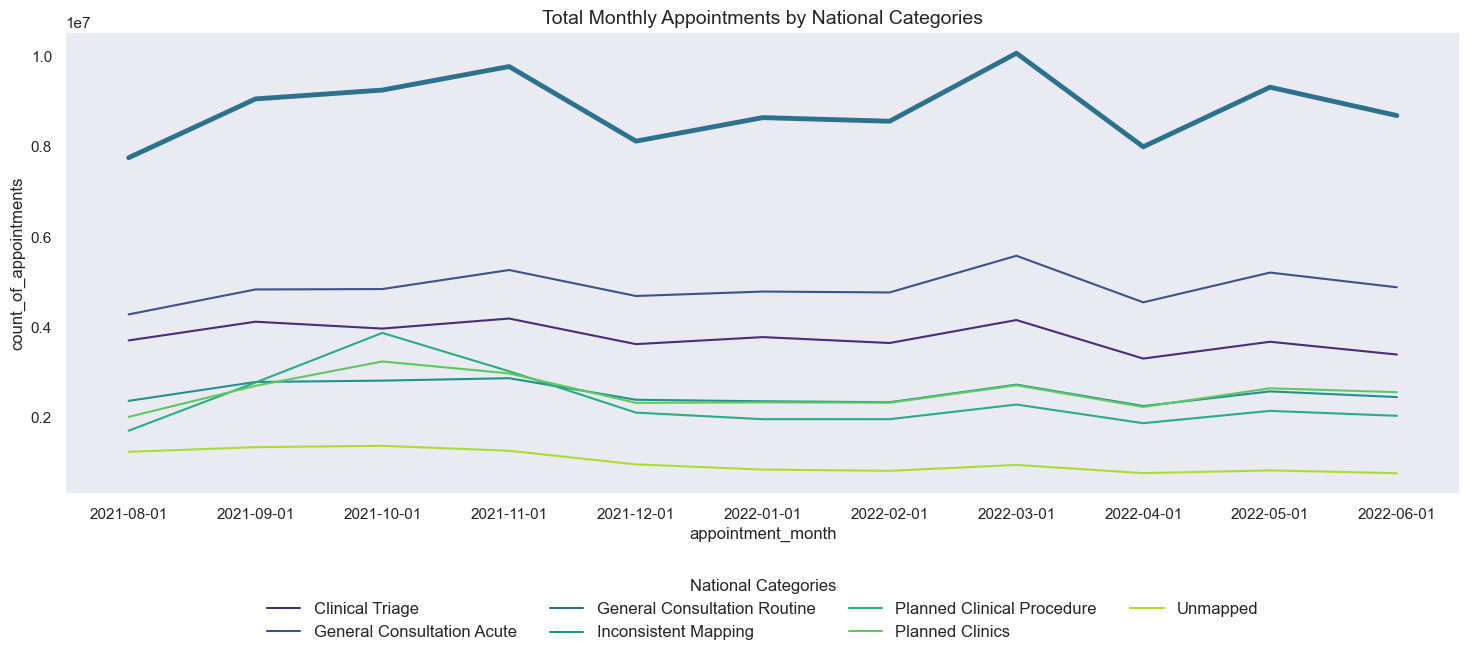

<Figure size 1500x1200 with 0 Axes>

In [450]:
# Due to the number of national categories (18), the chart focuses on the first seven to ensure a clearer presentation.
# List of national categories to include in the plot.
selected_categories = ['General Consultation Routine', 'General Consultation Acute', 'Clinical Triage',
                        'Planned Clinics', 'Inconsistent Mapping', 'Planned Clinical Procedure', 'Unmapped']

# Filter the DataFrame to include only the selected categories.
filtered_nc_nc = nc_nc[nc_nc['national_category'].isin(selected_categories)]

plt.figure(figsize=(18, 6))
# Create a line plot using the filtered data.
ax2 = sns.lineplot(x='appointment_month', y='count_of_appointments', hue='national_category',
                   data=filtered_nc_nc,
                   palette='viridis')

# Turn off grid lines.
ax2.grid(False)

plt.title('Total Monthly Appointments by National Categories', fontsize=14)

# Make the line for "Care Related Encounter" thicker.
care_related_encounter_line = ax2.lines[2]
care_related_encounter_line.set_linewidth(3.5)

# Change legend title and size and move it to the bottom.
ax2.legend(title='National Categories', bbox_to_anchor=(0.5, -0.15), loc='upper center', ncol=4, fontsize='medium')

# Show the plot.
plt.show()
plt.savefig('total_monthly_app_nc.png', dpi=96)

In [455]:
# Create 'day_of_week' column.
nc['day_of_week'] = nc['appointment_date'].dt.day_name()

# Group by both 'appointment_date' and the newly created 'day_of_week'
nc_day_of_week = nc.groupby(['appointment_date', 'day_of_week'])[['count_of_appointments']].sum().reset_index()

# View the output
nc_day_of_week.head()

,appointment_date,day_of_week,count_of_appointments
0,2021-08-01,Sunday,5627
1,2021-08-02,Monday,1222768
2,2021-08-03,Tuesday,1169920
3,2021-08-04,Wednesday,1093532
4,2021-08-05,Thursday,1074043


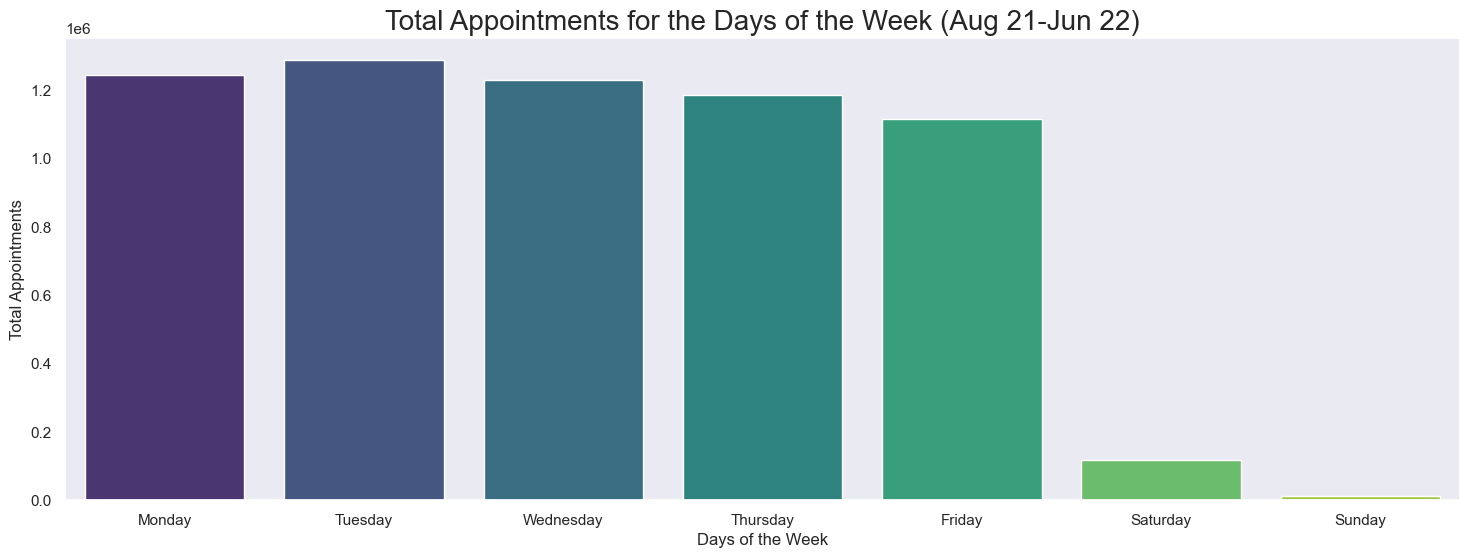

<Figure size 1500x1200 with 0 Axes>

In [456]:
# Order of days of the week.
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'] 

# Convert 'day_of_week' to categorical with the specified order.
nc_day_of_week['day_of_week'] = pd.Categorical(nc_day_of_week['day_of_week'], categories=day_order, ordered=True)

# Group by appointment day of the week for general practice appointments.
nc_day = nc_day_of_week.groupby(['day_of_week'])[['count_of_appointments']].sum().reset_index()

plt.figure(figsize=(18, 6))
sns.barplot(data=nc_day_of_week, x='day_of_week', y='count_of_appointments', palette='viridis', ci=None)

plt.title('Total Appointments for the Days of the Week (Aug 21-Jun 22)', fontsize=20)
plt.xlabel('Days of the Week')
plt.ylabel('Total Appointments')
plt.grid(False)

# Set the order of x-axis ticks.
plt.xticks(range(len(day_order)), day_order)

plt.show()
plt.savefig('total_app_dayofweek_ss.png', dpi=96)

Tuesdays stand out as the busiest day, securing the majority of appointments, closely followed by Mondays, accounting for bank holidays. In contrast, Sundays experience minimal appointment activity.

In [457]:
# Create dataframe to show total appointments for weekdays and weekends.
nc_weekdays = nc.groupby(['appointment_date','day_of_week'])[['count_of_appointments']].sum()\
        .reset_index()
       
nc_weekdays

,appointment_date,day_of_week,count_of_appointments
0,2021-08-01,Sunday,5627
1,2021-08-02,Monday,1222768
2,2021-08-03,Tuesday,1169920
3,2021-08-04,Wednesday,1093532
4,2021-08-05,Thursday,1074043
...,...,...,...
329,2022-06-26,Sunday,6574
330,2022-06-27,Monday,1410883
331,2022-06-28,Tuesday,1335598
332,2022-06-29,Wednesday,1237258


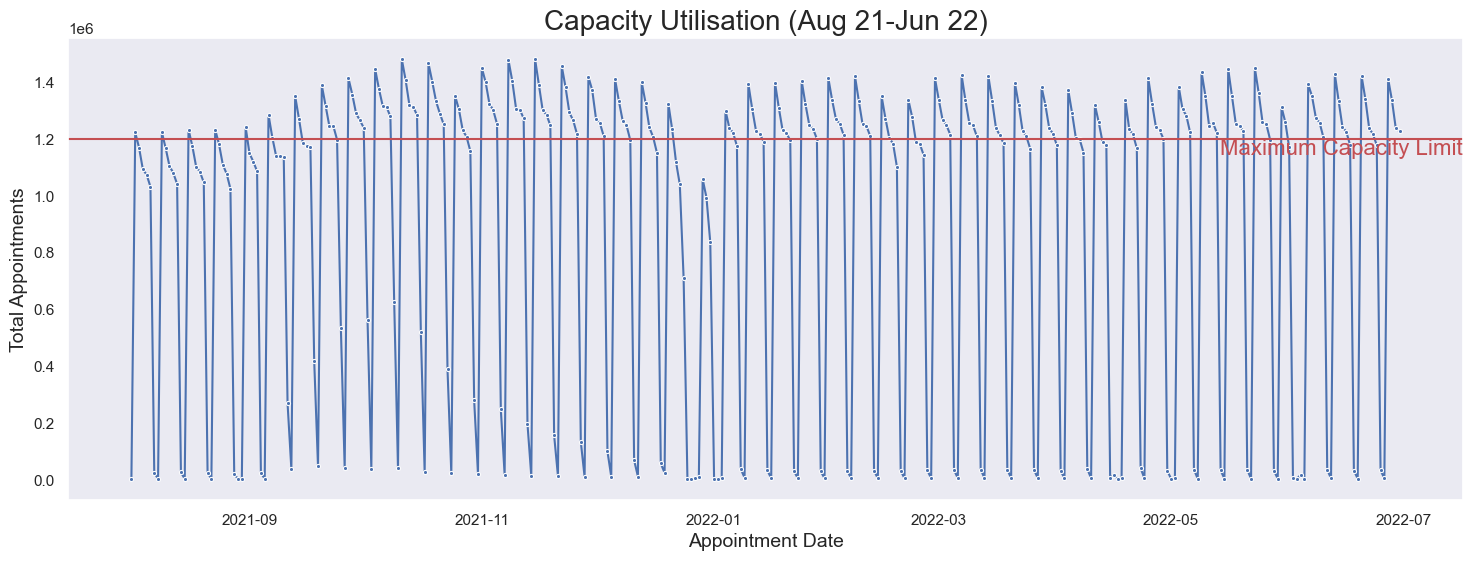

In [458]:
# Plot a line graph of sum of appointments by day from the nc DataFrame.
plt.figure(figsize=(18, 6))

# Plot a line graph of sum of appointments by day from the nc DataFrame.
sns.lineplot(data=nc_weekdays, x='appointment_date', y='count_of_appointments',
             marker='.', palette='viridis')

plt.title('Capacity Utilisation (Aug 21-Jun 22)', fontsize=20)
plt.xlabel('Appointment Date', fontsize=14)
plt.ylabel('Total Appointments', fontsize=14)
plt.grid(False)

# Show the 1,200,000 appointments limit.
plt.axhline(y=1200000, color='r', linestyle='-', label='Maximum Capacity Limit')
plt.text(plt.xlim()[1], 1200000, 'Maximum Capacity Limit', color='r', ha='right', va='top', fontsize=16)

# Display the plot.
plt.show()

### Objective 2


The seasons are **summer** (June to August 2021), **autumn** (September to November 2021), **winter** (December to February 2022), and **spring** (March to May 2022).

**Summer:**


In [459]:
# The 'nc' dataset does not contain Jun and July 2021, therefore the output only shows August 2021.
# Check the unique values in 'appointment_month' in the original DataFrame.
print(nc['appointment_month'].unique())

# Create a separate data set for summer (June to August 2021).
nc_summer = nc[nc['appointment_month'].between('2021-06', '2021-08')]

# Group by 'appointment_month' and 'service_setting' and calculate the sum of 'count_of_appointments'.
nc_summer_table = pd.pivot_table(nc_summer, values='count_of_appointments',
                                 index='service_setting', columns='appointment_month', aggfunc='sum', fill_value=0)

# View the output.
nc_summer_table

['2021-08-01' '2021-09-01' '2021-10-01' '2021-11-01' '2021-12-01'
 '2022-01-01' '2022-02-01' '2022-03-01' '2022-04-01' '2022-05-01'
 '2022-06-01']


appointment_month
service_setting


In [460]:
# The 'nc' dataset does not contain Jun and July 2021, therefore, the focus will be on August 2021.
# Aggregate August 2021 data based on service settings to display the total number of appointments a daily basis.
nc_aug21 = nc[nc['appointment_date'].between('2021-08-01', '2021-08-31')]

# Group by appointment date and service setting, and calculate the sum of appointments.
nc_aug21 = nc_aug21.groupby(['appointment_date', 'service_setting'])[['count_of_appointments']].sum().reset_index()

nc_aug21

,appointment_date,service_setting,count_of_appointments
0,2021-08-01,Extended Access Provision,438
1,2021-08-01,General Practice,3411
2,2021-08-01,Other,401
3,2021-08-01,Primary Care Network,323
4,2021-08-01,Unmapped,1054
...,...,...,...
150,2021-08-31,Extended Access Provision,8281
151,2021-08-31,General Practice,1125584
152,2021-08-31,Other,23181
153,2021-08-31,Primary Care Network,21789


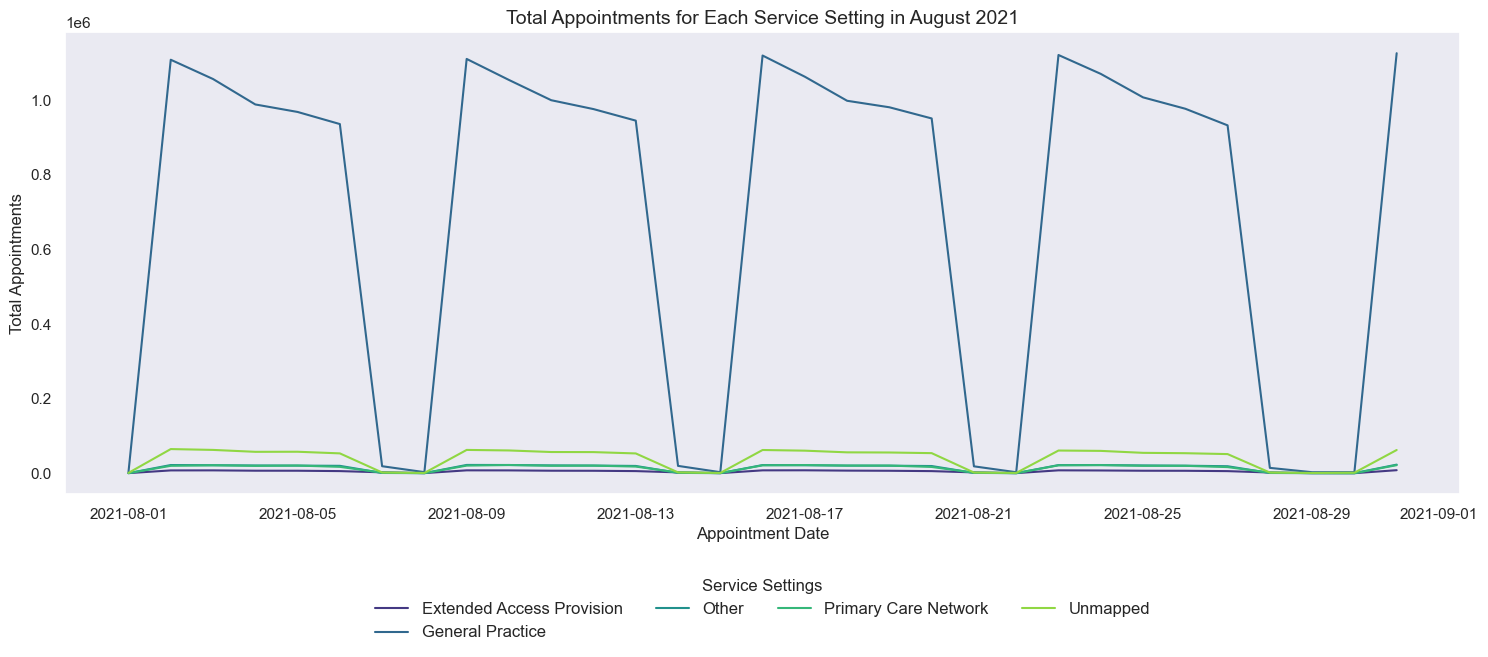

<Figure size 1500x1200 with 0 Axes>

In [461]:
# Visualise the subset using a lineplot.
plt.figure(figsize=(18, 6))
sns.set(style="darkgrid")

plt.grid(False)
sns.lineplot(data=nc_aug21, x='appointment_date', y='count_of_appointments', hue='service_setting', palette='viridis')
plt.title('Total Appointments for Each Service Setting in August 2021', fontsize=14)
plt.xlabel('Appointment Date')
plt.ylabel('Total Appointments')

# Move the legend to the bottom.
plt.legend(title='Service Settings', bbox_to_anchor=(0.5, -0.15), loc='upper center', ncol=4, fontsize='medium')

# View and save the plot.
plt.show()
plt.savefig('total_daily_app_ss_aug21.png', dpi=96)

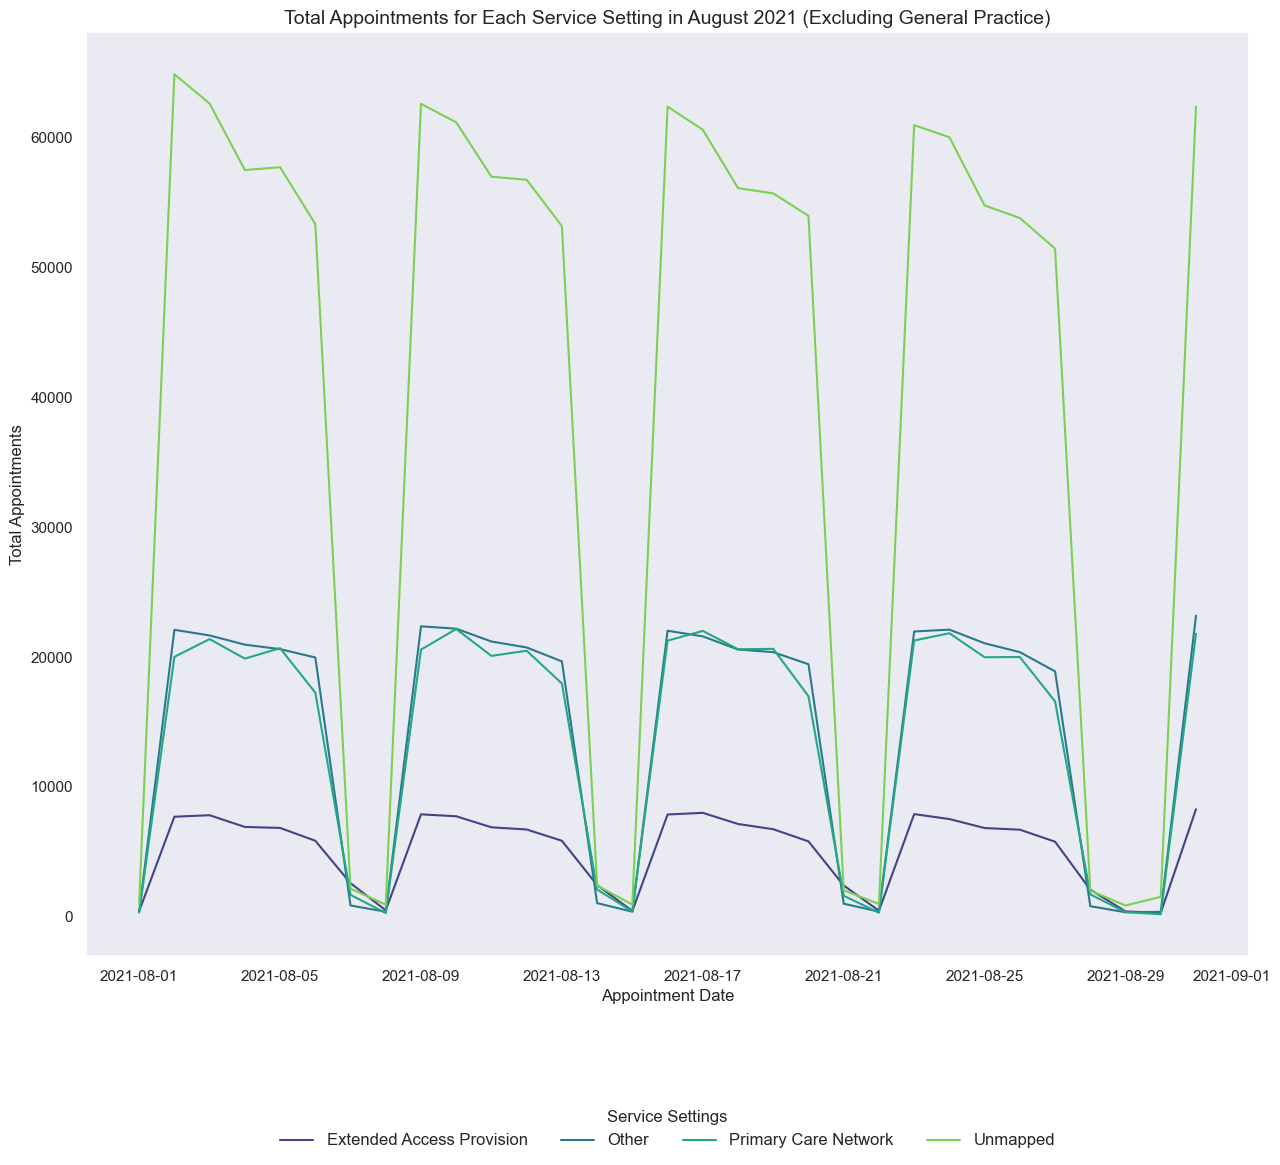

<Figure size 1500x1200 with 0 Axes>

In [462]:
# Filter out General Practice in service setting
nc_aug21_filtered = nc_aug21[nc_aug21['service_setting'] != 'General Practice']

# Visualise the subset using a lineplot.
sns.set(style="darkgrid")

plt.grid(False)
sns.lineplot(data=nc_aug21_filtered, x='appointment_date', y='count_of_appointments', hue='service_setting', palette='viridis')
plt.title('Total Appointments for Each Service Setting in August 2021 (Excluding General Practice)', fontsize=14)
plt.xlabel('Appointment Date')
plt.ylabel('Total Appointments')

# Move the legend to the bottom.
plt.legend(title='Service Settings', bbox_to_anchor=(0.5, -0.15), loc='upper center', ncol=4, fontsize='medium')

# View and save the plot.
plt.show()
plt.savefig('total_daily_app_ss_aug21_filtered.png', dpi=96)

**Autumn:**

In [463]:
# Create a separate data set for autumn (Sept to Nov 2021).
nc_aut21 = nc[nc['appointment_date'].between('2021-09', '2021-11')]

# Group by appointment date and service setting, and calculate the sum of appointments.
nc_aut21 = nc_aut21.groupby(['appointment_date', 'service_setting'])[['count_of_appointments']].sum().reset_index()

nc_aut21

,appointment_date,service_setting,count_of_appointments
0,2021-09-01,Extended Access Provision,6916
1,2021-09-01,General Practice,1041879
2,2021-09-01,Other,21796
3,2021-09-01,Primary Care Network,21371
4,2021-09-01,Unmapped,57423
...,...,...,...
305,2021-11-01,Extended Access Provision,9405
306,2021-11-01,General Practice,1327886
307,2021-11-01,Other,25726
308,2021-11-01,Primary Care Network,26350


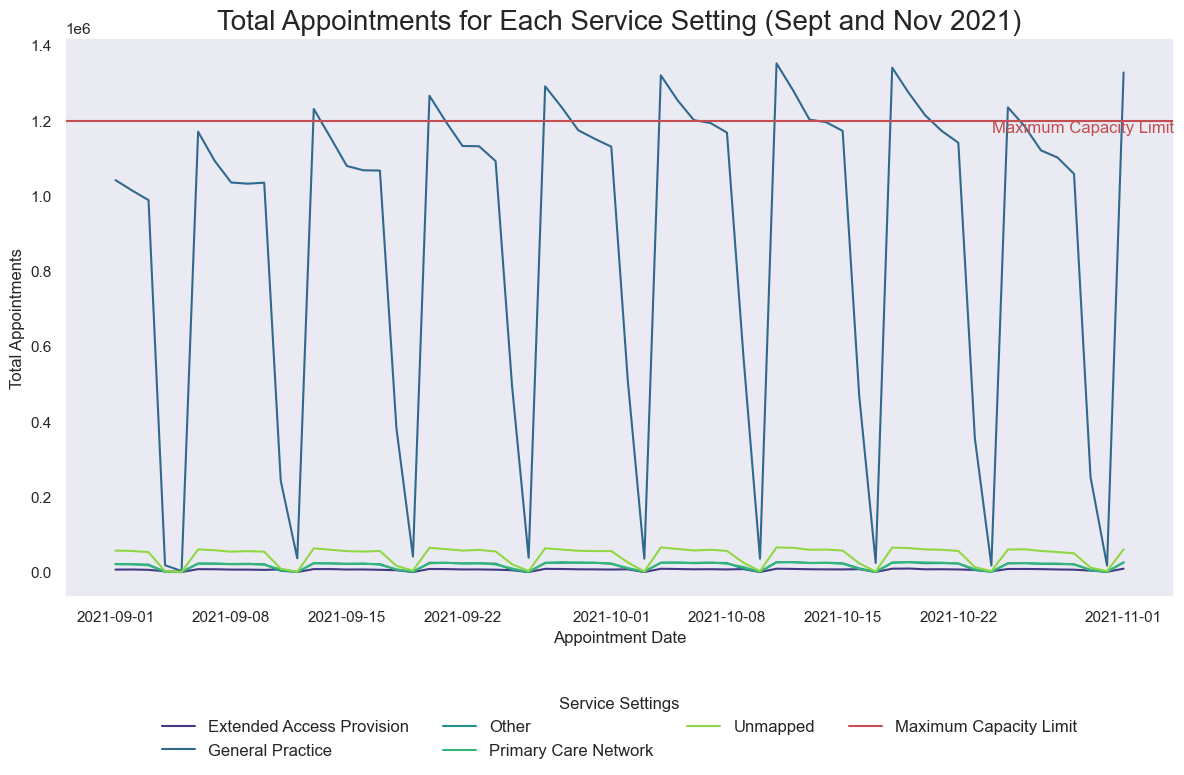

<Figure size 1500x1200 with 0 Axes>

In [464]:
# Visualise the subset using a lineplot.
plt.figure(figsize=(12, 8))
plt.grid(False)
sns.lineplot(data=nc_aut21, x='appointment_date', y='count_of_appointments', hue='service_setting', palette='viridis')
plt.title('Total Appointments for Each Service Setting (Sept and Nov 2021)', fontsize=20)
plt.xlabel('Appointment Date')
plt.ylabel('Total Appointments')

# Show the 1,200,000 appointments limit.
plt.axhline(y=1200000, color='r', linestyle='-', label='Maximum Capacity Limit')
plt.text(plt.xlim()[1], 1200000, 'Maximum Capacity Limit', color='r', ha='right', va='top')

# Move the legend to the bottom.
plt.legend(title='Service Settings', bbox_to_anchor=(0.5, -0.15), loc='upper center', ncol=4, fontsize='medium')

# View and save the plot.
plt.tight_layout() 
plt.show()
plt.savefig('total_app_ss_autumn21.png', dpi=96)

**Winter:**

In [465]:
# Create a separate data set for winter (December to February 2022).
nc_wint21 = nc[nc['appointment_date'].between('2021-12', '2022-02')]

# Group by appointment date and service setting, and calculate the sum of appointments.
nc_wint21 = nc_wint21.groupby(['appointment_date', 'service_setting'])[['count_of_appointments']].sum().reset_index()

# View the output.
nc_wint21

,appointment_date,service_setting,count_of_appointments
0,2021-12-01,Extended Access Provision,8500
1,2021-12-01,General Practice,1162676
2,2021-12-01,Other,22924
3,2021-12-01,Primary Care Network,26887
4,2021-12-01,Unmapped,49064
...,...,...,...
310,2022-02-01,Extended Access Provision,9791
311,2022-02-01,General Practice,1229653
312,2022-02-01,Other,23762
313,2022-02-01,Primary Care Network,30891


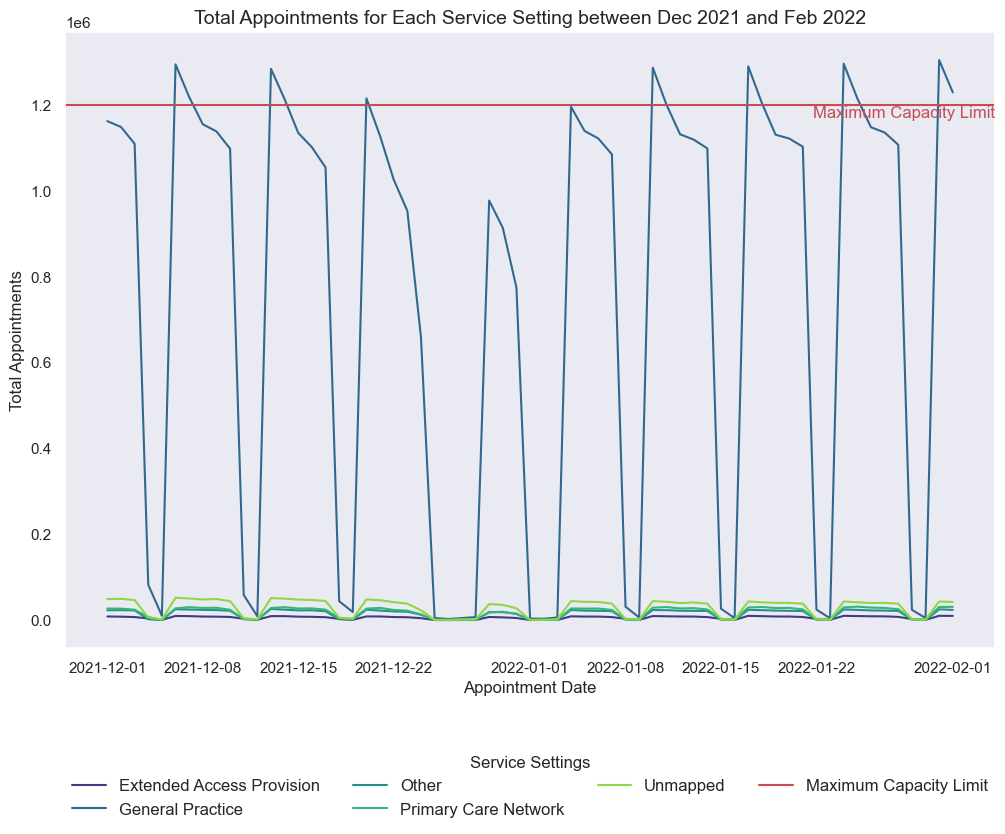

<Figure size 1500x1200 with 0 Axes>

In [466]:
# Visualise the subset using a lineplot.
plt.figure(figsize=(12, 8))
plt.grid(False)
sns.lineplot(data=nc_wint21, x='appointment_date', y='count_of_appointments', hue='service_setting', palette='viridis')
plt.title('Total Appointments for Each Service Setting between Dec 2021 and Feb 2022', fontsize=14)
plt.xlabel('Appointment Date')
plt.ylabel('Total Appointments')

# Show the 1,200,000 appointments limit.
plt.axhline(y=1200000, color='r', linestyle='-', label='Maximum Capacity Limit')
plt.text(plt.xlim()[1], 1200000, 'Maximum Capacity Limit', color='r', ha='right', va='top')

# Move the legend to the bottom.
plt.legend(title='Service Settings', bbox_to_anchor=(0.5, -0.15), loc='upper center', ncol=4, fontsize='medium')

# View and save the plot.
plt.show()
plt.savefig('total_app_ss_winter21.png', dpi=96)

**Spring:**

In [467]:
# Create a separate data set for spring (March to May 2022).
nc_spri21 = nc[nc['appointment_date'].between('2022-03', '2022-05')]

# Group by appointment date and service setting, and calculate the sum of appointments.
nc_spri21 = nc_spri21.groupby(['appointment_date', 'service_setting'])[['count_of_appointments']].sum().reset_index()

# View the output.
nc_spri21

,appointment_date,service_setting,count_of_appointments
0,2022-03-01,Extended Access Provision,10082
1,2022-03-01,General Practice,1229045
2,2022-03-01,Other,23986
3,2022-03-01,Primary Care Network,32070
4,2022-03-01,Unmapped,42682
...,...,...,...
305,2022-05-01,Extended Access Provision,572
306,2022-05-01,General Practice,3569
307,2022-05-01,Other,435
308,2022-05-01,Primary Care Network,424


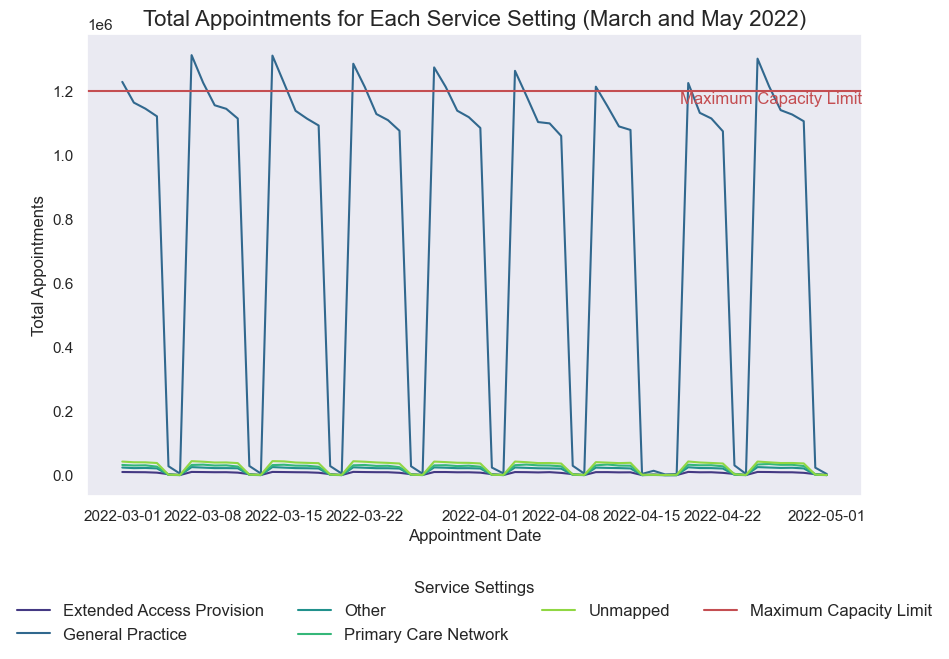

<Figure size 1500x1200 with 0 Axes>

In [468]:
# Visualise the subset using a lineplot.
plt.figure(figsize=(10, 6))
plt.grid(False)
sns.lineplot(data=nc_spri21, x='appointment_date', y='count_of_appointments', hue='service_setting', palette='viridis')
plt.title('Total Appointments for Each Service Setting (March and May 2022)', fontsize=16)
plt.xlabel('Appointment Date')
plt.ylabel('Total Appointments')

# Show the 1,200,000 appointments limit.
plt.axhline(y=1200000, color='r', linestyle='-', label='Maximum Capacity Limit')
plt.text(plt.xlim()[1], 1200000, 'Maximum Capacity Limit', color='r', ha='right', va='top')

# Move the legend to the bottom.
plt.legend(title='Service Settings', bbox_to_anchor=(0.5, -0.15), loc='upper center', ncol=4, fontsize='medium')

# View and save the plot.
plt.show()
plt.savefig('total_app_ss_spring21.png', dpi=72)

## 5) Assignment activity 5

### Analyse tweets from Twitter with hashtags related to healthcare in the UK.

In [469]:
# Libraries and settings needed for analysis.
import pandas as pd
import seaborn as sns

# Set the figure size.
sns.set(rc={'figure.figsize':(15, 12)})
sns.set(style='darkgrid', palette='viridis')

# Maximum column width to display.
pd.options.display.max_colwidth = 200

In [470]:
# Load the data set.
tweets = pd.read_csv('tweets.csv')

# View the DataFrame.
tweets

,tweet_id,tweet_full_text,tweet_entities,tweet_entities_hashtags,tweet_metadata,tweet_retweet_count,tweet_favorite_count,tweet_favorited,tweet_retweeted,tweet_lang
0,1567629223795527681,"As Arkansas’ first Comprehensive Stroke Certified Center, UAMS provides Arkansans with access to the most advanced stoke care. Join us in our mission to make a difference in the health and well-be...","{'hashtags': [{'text': 'Healthcare', 'indices': [253, 264]}], 'symbols': [], 'user_mentions': [], 'urls': [{'url': 'https://t.co/yw0cstfmSI', 'expanded_url': 'https://bit.ly/3BiSKbs', 'display_url...",#Healthcare,"{'iso_language_code': 'en', 'result_type': 'recent'}",0,0,False,False,en
1,1567582846612553728,RT @AndreaGrammer: Work-life balance is at the foundation of how decisions are made and where #PremiseHealth is headed. We're #hiring for…,"{'hashtags': [{'text': 'PremiseHealth', 'indices': [94, 108]}, {'text': 'hiring', 'indices': [127, 134]}], 'symbols': [], 'user_mentions': [{'screen_name': 'AndreaGrammer', 'name': 'Andrea Grammer...","#PremiseHealth, #hiring","{'iso_language_code': 'en', 'result_type': 'recent'}",2,0,False,False,en
2,1567582787070304256,RT @OntarioGreens: $10 billion can go a long way to fixing our broken #Healthcare system.\n\nYet Doug Ford would rather spend it ALL on a hig…,"{'hashtags': [{'text': 'Healthcare', 'indices': [70, 81]}], 'symbols': [], 'user_mentions': [{'screen_name': 'OntarioGreens', 'name': 'Green Party of Ontario', 'id': 37115912, 'id_str': '37115912'...",#Healthcare,"{'iso_language_code': 'en', 'result_type': 'recent'}",39,0,False,False,en
3,1567582767625428992,RT @modrnhealthcr: 🚨#NEW:🚨 Insurance companies are figuring out the best ways to collect information about members’ race and ethnicity data…,"{'hashtags': [{'text': 'NEW', 'indices': [20, 24]}], 'symbols': [], 'user_mentions': [{'screen_name': 'modrnhealthcr', 'name': 'Modern Healthcare', 'id': 18935711, 'id_str': '18935711', 'indices':...",#NEW,"{'iso_language_code': 'en', 'result_type': 'recent'}",5,0,False,False,en
4,1567582720460570625,"ICYMI: Our recent blogs on Cybersecurity in Accounting https://t.co/4nnK0FiVVL and Digital Transformation in Healthcare Finance https://t.co/jIqn52lHD3 are a great read, take a look!\n\n#blogs #di...","{'hashtags': [{'text': 'blogs', 'indices': [184, 190]}, {'text': 'digitaltransformation', 'indices': [191, 213]}, {'text': 'cybersecurity', 'indices': [214, 228]}, {'text': 'accounting', 'indices'...","#blogs, #digitaltransformation, #cybersecurity, #accounting, #finance, #healthcare","{'iso_language_code': 'en', 'result_type': 'recent'}",0,0,False,False,en
...,...,...,...,...,...,...,...,...,...,...
1169,1567583004209332227,RT @PotomacPhotonic: Potomac #Innovation Report: #precisionFabrication techniques Optimize #Microfluidic Mixing of Viscous Fluids \n\n#manuf…,"{'hashtags': [{'text': 'Innovation', 'indices': [29, 40]}, {'text': 'precisionFabrication', 'indices': [50, 71]}, {'text': 'Microfluidic', 'indices': [92, 105]}], 'symbols': [], 'user_mentions': [...","#Innovation, #precisionFabrication, #Microfluidic","{'iso_language_code': 'en', 'result_type': 'recent'}",1,0,False,False,en
1170,1567582945342267393,"Not a cent towards workers who would like to advance their training, especially those already employed by SHA or who for various reasons cannot obtain a student loan. Half of our department applie...","{'hashtags': [{'text': 'SKPoli', 'indices': [232, 239]}, {'text': 'healthcare', 'indices': [240, 251]}], 'symbols': [], 'user_mentions': [], 'urls': [{'url': 'https://t.co/33f7Dz5FrU', 'expanded_u...","#SKPoli, #healthcare","{'iso_language_code': 'en', 'result_type': 'recent'}",0,1,False,False,en
1171,1567582936014241792,"The @hfmaorg Region 9 presents ""The Value of ESG to the Healthcare Industry"" and our own Kris Russell and Ron Present will be the key speakers. This #webinar will be taking place 9/13 and will exp...","{'hashtags': [{'text': 'webinar', 'indices': [149, 157]}, {'text': 'ESG', 'indices'

In [471]:
# Explore the metadata and data set.
tweets.info()
tweets.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1174 entries, 0 to 1173
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   tweet_id                 1174 non-null   int64 
 1   tweet_full_text          1174 non-null   object
 2   tweet_entities           1174 non-null   object
 3   tweet_entities_hashtags  1007 non-null   object
 4   tweet_metadata           1174 non-null   object
 5   tweet_retweet_count      1174 non-null   int64 
 6   tweet_favorite_count     1174 non-null   int64 
 7   tweet_favorited          1174 non-null   bool  
 8   tweet_retweeted          1174 non-null   bool  
 9   tweet_lang               1174 non-null   object
dtypes: bool(2), int64(3), object(5)
memory usage: 75.8+ KB


,tweet_id,tweet_retweet_count,tweet_favorite_count
count,1.174000e+03,1174.000000,1174.00000
mean,1.567612e+18,8.629472,0.37138
std,2.427553e+13,29.784675,2.04470
min,1.567574e+18,0.000000,0.00000
25%,1.567590e+18,0.000000,0.00000
50%,1.567611e+18,1.000000,0.00000
75%,1.567633e+18,3.000000,0.00000
max,1.567655e+18,303.000000,42.00000


#### Would it be useful to only look at retweeted and favourite tweet messages?
#### Explain your answer.
Analyzing retweeted and favorited tweets is valuable as it provides insights into the popularity, engagement, and effectiveness of messages within a community, helping identify influential content and improve future messaging strategies.

In [472]:
# Analyse retweeted and favorite tweet messages.
# Filter for retweeted and favorited tweets.
retweeted_and_favorited_tweets = tweets[(tweets['tweet_retweeted'] == True) & (tweets['tweet_favorite_count'] > 0)]

# view the output.
print(retweeted_and_favorited_tweets[['tweet_id', 'tweet_retweet_count', 'tweet_favorite_count']])

Empty DataFrame
Columns: [tweet_id, tweet_retweet_count, tweet_favorite_count]
Index: []


**The DataFrame filtered for retweeted and favorited tweets is empty, suggesting no tweets meet both criteria (being retweeted with a favorite count greater than 0).**

In [473]:
# Analyse retweeted tweets.
retweeted_tweets = tweets[tweets['tweet_retweeted'] == True]

# Analyse and sort favorited tweets.
favorited_tweets = tweets[tweets['tweet_favorite_count'] > 0].sort_values(by='tweet_favorite_count', ascending=False)

# View the output for retweeted tweets.
print("Retweeted Tweets:")
print(retweeted_tweets[['tweet_id', 'tweet_retweet_count', 'tweet_favorite_count']])

# VIew the output for favorited tweets.
print("\nFavorited Tweets:")
favorited_tweets[['tweet_id', 'tweet_full_text', 'tweet_retweet_count', 'tweet_favorite_count']].head(10)

Retweeted Tweets:
Empty DataFrame
Columns: [tweet_id, tweet_retweet_count, tweet_favorite_count]
Index: []

Favorited Tweets:


,tweet_id,tweet_full_text,tweet_retweet_count,tweet_favorite_count
1156,1567583855422611461,Lipid-Lowering Drugs\n\n#TipsForNewDocs #MedEd #MedTwitter #medicine #medical #medicare #health #healthcare #FOAMed #ClinicalPearl #clinicaltips #MedStudents #medstudenttwitter #lipid \n\nCredit: ...,12,42
9,1567582427719282689,You ready for $JCO @_JennyCo ❤️\n\n#Healthcare data powered by @Conste11ation $DAG 🔥,1,28
442,1567634936341069826,How health insurance works 😂 \n\n#comedy #adulting #healthcare https://t.co/ciksdeoAkb,5,20
84,1567579049043832832,"Our nat’l choices re: #healthcare systems aren’t the continuum of public or private, but how much we want of:\n\n- fragmented or seamless\n- does simplicity or complexity well\n- prioritizes savin...",4,18
1122,1567586306607423488,"Heart Failure, Myocardial Infarction &amp; immediate Treatment\n\n#TipsForNewDocs #MedEd #MedTwitter #medicine #medical #medicare #health #healthcare #FOAMed #ClinicalPearl #clinicaltips #MedStude...",3,17
119,1567577266162475011,"More data that our 13+ 🇨🇦 #healthcare systems fall short of providing adequate access to care, even for those w/ a family physician.\n\nInstead of siloed solutions and further system fragmentation...",4,14
758,1567611240024875008,Looking forward to speaking at #ConV2X on Sep 15! Ping me for a speaker discount if interested! Register at https://t.co/v20ebbXmdO \n\n.@BHTYjournal @hedera @acoerco\n#blockchain #DLT #healthcare...,3,13
1098,1567587492949286912,@CapricornFMNews We have waiting to hear this kind of news now Sa is getting things correct there is absolutely nothing mahala #HealthCare services in SA must be paid by foreign nationals and loca...,0,12
342,1567643206480699392,September is #WomenInMedicine Month! Thrilled to join @JulieSilverMD #SheLeadsHealthcare @ELAMProgram &amp; @AMWADoctors to #InvestInHer!\n\nI #InvestInHer to diversify the #healthcare #leadersh...,8,11
1093,1567588119892971520,Thanks &amp; Happy #WomenInMedicine Month to AMWA Board Member @SusanHingle! We appreciate your contributions to #Healthcare &amp; your leadership in AMWA! Learn about AMWA's community &amp; initi...,5,10


In [474]:
# Create a new DataFrame containing only the text.
text_only = tweets[['tweet_full_text']]

# View the new DataFrame.
text_only

,tweet_full_text
0,"As Arkansas’ first Comprehensive Stroke Certified Center, UAMS provides Arkansans with access to the most advanced stoke care. Join us in our mission to make a difference in the health and well-be..."
1,RT @AndreaGrammer: Work-life balance is at the foundation of how decisions are made and where #PremiseHealth is headed. We're #hiring for…
2,RT @OntarioGreens: $10 billion can go a long way to fixing our broken #Healthcare system.\n\nYet Doug Ford would rather spend it ALL on a hig…
3,RT @modrnhealthcr: 🚨#NEW:🚨 Insurance companies are figuring out the best ways to collect information about members’ race and ethnicity data…
4,"ICYMI: Our recent blogs on Cybersecurity in Accounting https://t.co/4nnK0FiVVL and Digital Transformation in Healthcare Finance https://t.co/jIqn52lHD3 are a great read, take a look!\n\n#blogs #di..."
...,...
1169,RT @PotomacPhotonic: Potomac #Innovation Report: #precisionFabrication techniques Optimize #Microfluidic Mixing of Viscous Fluids \n\n#manuf…
1170,"Not a cent towards workers who would like to advance their training, especially those already employed by SHA or who for various reasons cannot obtain a student loan. Half of our department applie..."
1171,"The @hfmaorg Region 9 presents ""The Value of ESG to the Healthcare Industry"" and our own Kris Russell and Ron Present will be the key speakers. This #webinar will be taking place 9/13 and will exp..."
1172,Happy physiotherapy 🩺 day 🎉..\n#bpt #physiotherapy \n#HealthyNation #healthcare \n#medicalcare \n#csjmu .\n@WHO \n@MoHFW_INDIA \n@nitish_0210 https://t.co/NQHdIoYymC


In [475]:
# Loop through the messages, and create a list of values containing the # symbol.
# Create an empty list to store values containing the '#' symbol.
hashtags = []

for y in [x.split(' ') for x in tweets['tweet_full_text'].values]:
    for z in y:
        if '#' in z:
            # Change to lowercase.
            hashtags.append(z.lower())
            
hashtags_series = pd.Series(hashtags).value_counts()

In [476]:
# Display the first 30 records.
print(hashtags_series.head(30))

#healthcare                    716
#health                         80
#medicine                       41
#ai                             40
#job                            38
#medical                        35
#strategy                       30
#pharmaceutical                 28
#digitalhealth                  25
#pharma                         25
#marketing                      25
#medtwitter                     24
#biotech                        24
#competitiveintelligence        24
#meded                          23
#vaccine                        18
#hiring                         18
#news                           17
#machinelearning                17
#technology                     17
#coronavirus                    16
#womeninmedicine                16
#covid                          16
#competitivemarketing           16
#wellness                       15
#healthtech                     15
#doctorofveterinarymedicine     14
#science                        14
#medicare           

In [477]:
# Convert the series to a DataFrame in preparation for visualisation.
# Rename the columns.
hashtags1 = hashtags_series.reset_index()
hashtags1.columns = ['Hashtag', 'Count']

In [478]:
# Fix the count datatype.
hashtags1['Count'] = hashtags1['Count'].astype(int)

# View the result.
hashtags1

,Hashtag,Count
0,#healthcare,716
1,#health,80
2,#medicine,41
3,#ai,40
4,#job,38
...,...,...
1749,#evestudy,1
1750,#patientdata…,1
1751,#secure,1
1752,#sms,1


In [479]:
# Display records where the count is larger than 10.
hashtags1 = hashtags1[hashtags1['Count'] > 10]

hashtags1

,Hashtag,Count
0,#healthcare,716
1,#health,80
2,#medicine,41
3,#ai,40
4,#job,38
5,#medical,35
6,#strategy,30
7,#pharmaceutical,28
8,#digitalhealth,25
9,#pharma,25


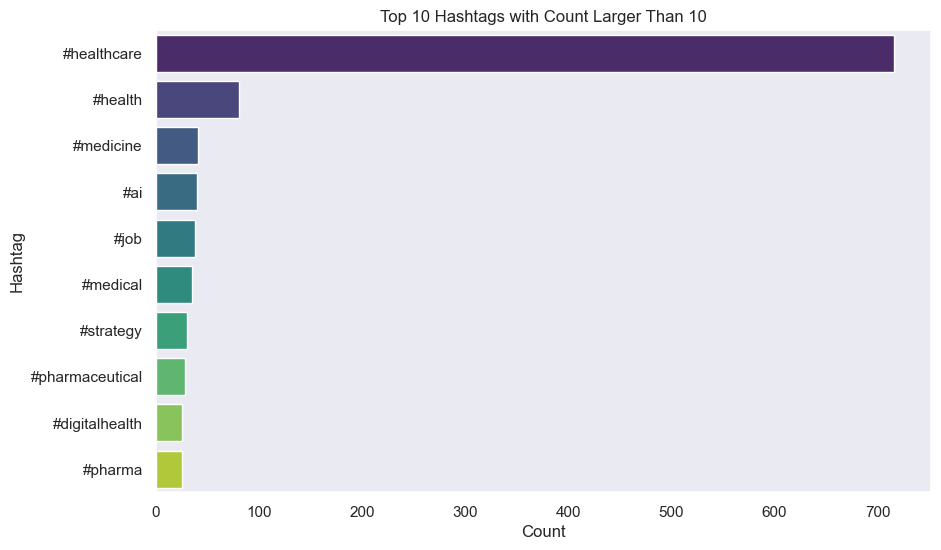

<Figure size 1500x1200 with 0 Axes>

In [480]:
# Limited to the top 10 hashtags for ensuring a more manageable presentation on the chart.
# Create the plot.
hashtags1 = hashtags1[hashtags1['Count'] > 10].head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x='Count', y='Hashtag', data=hashtags1, palette='viridis')

# Turn off grid lines.
plt.grid(False)

# Set plot title and labels.
plt.title('Top 10 Hashtags with Count Larger Than 10')
plt.xlabel('Count')
plt.ylabel('Hashtag')

# View the barplot.
plt.show()
plt.savefig('hashtags', dpi=96)

**Healthcare dominates with 716 occurrences, emphasizing a strong focus on healthcare topics in the dataset, as this chart suggests that healthcare is the most discussed topic on Twitter. However, it's important to note that the source of this data is unknown. Upon reviewing the comments on Twitter, it becomes apparent that some discussions are unrelated to the NHS, including comments about America. The absence of specific information about NHS-related topics such as waiting times, appointments, or NHS staffing renders this data source less relevant for the intended analysis. Therefore, Twitter analysis will not be incorporated into this report.**

## 6) Assignment activity 6


### Investigate the main concerns posed by the NHS. 

In [481]:
# Prepare your workstation.
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set figure size.
sns.set(rc={'figure.figsize':(10, 6)})
sns.set_palette('viridis')

# Sense-check for 'ar'.
print(ar_cleaned.shape)
print(ar_cleaned.dtypes)
print(ar_cleaned.columns)

# View the DataFrame.
ar_cleaned

(575217, 7)
icb_ons_code                         object
appointment_month                    object
appointment_status                   object
hcp_type                             object
appointment_mode                     object
time_between_book_and_appointment    object
count_of_appointments                 int64
dtype: object
Index(['icb_ons_code', 'appointment_month', 'appointment_status', 'hcp_type',
       'appointment_mode', 'time_between_book_and_appointment',
       'count_of_appointments'],
      dtype='object')


,icb_ons_code,appointment_month,appointment_status,hcp_type,appointment_mode,time_between_book_and_appointment,count_of_appointments
0,E54000034,2020-01,Attended,GP,Face-to-Face,1 Day,8107
1,E54000034,2020-01,Attended,GP,Face-to-Face,15 to 21 Days,6791
2,E54000034,2020-01,Attended,GP,Face-to-Face,2 to 7 Days,20686
3,E54000034,2020-01,Attended,GP,Face-to-Face,22 to 28 Days,4268
4,E54000034,2020-01,Attended,GP,Face-to-Face,8 to 14 Days,11971
...,...,...,...,...,...,...,...
596813,E54000050,2022-06,Unknown,Unknown,Telephone,Same Day,10
596815,E54000050,2022-06,Unknown,Unknown,Unknown,15 to 21 Days,13
596816,E54000050,2022-06,Unknown,Unknown,Unknown,2 to 7 Days,21
596818,E54000050,2022-06,Unknown,Unknown,Unknown,8 to 14 Days,28


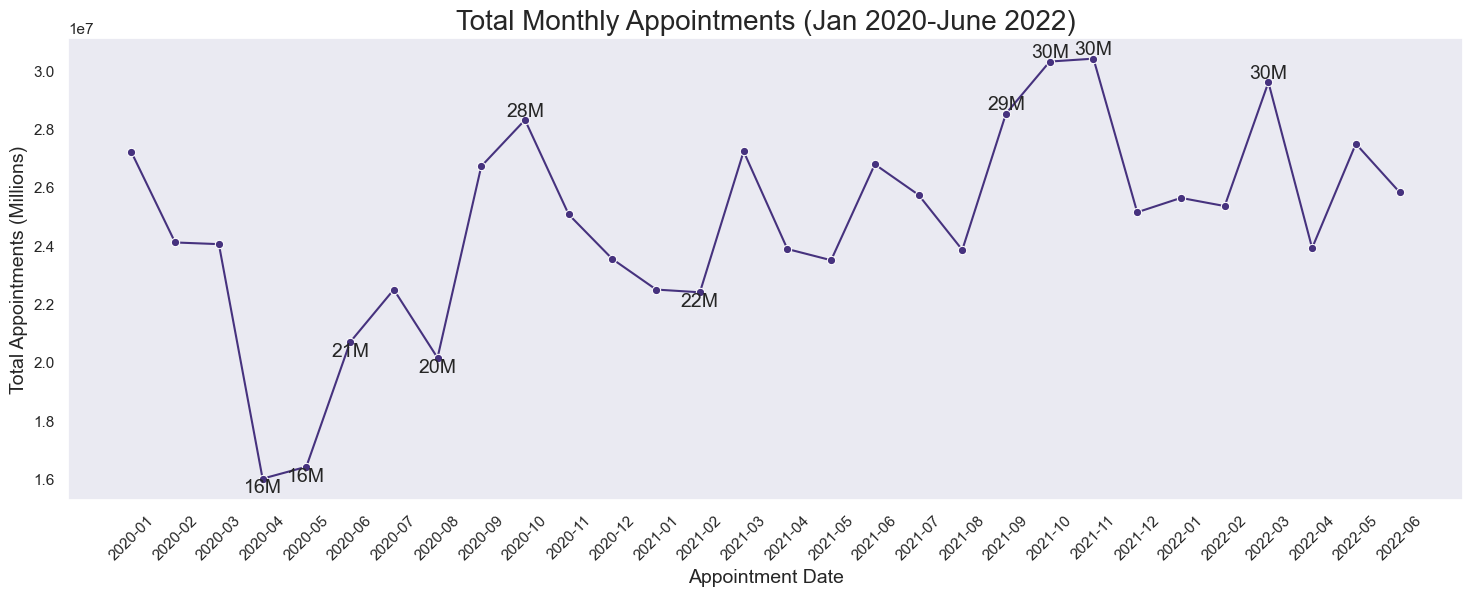

In [482]:
# Create line plot to see the total monthly appointments from Jan 20 to Jun 22.
ar_app = ar_cleaned.groupby('appointment_month')[['count_of_appointments']].sum().reset_index()

# Plot a line graph of sum of appointments by month from the ar_clean DataFrame.
plt.figure(figsize=(18, 6))
ax = sns.lineplot(data=ar_app, x='appointment_month', y='count_of_appointments', marker='o')

# Add data labels to the top 5 highest and top 5 lowest points
top5_highest = ar_app.nlargest(5, 'count_of_appointments')
top5_lowest = ar_app.nsmallest(5, 'count_of_appointments')

for index, value in top5_highest.iterrows():
    count_label = f'{round(value["count_of_appointments"] / 1_000_000):,}M'
    ax.text(value['appointment_month'], value['count_of_appointments'], count_label,
            ha='center', va='bottom', fontsize=14)

for index, value in top5_lowest.iterrows():
    count_label = f'{round(value["count_of_appointments"] / 1_000_000):,}M'
    ax.text(value['appointment_month'], value['count_of_appointments'], count_label,
            ha='center', va='top', fontsize=14)

plt.title('Total Monthly Appointments (Jan 2020-June 2022)', fontsize=20)
plt.xlabel('Appointment Date', fontsize=14)
plt.ylabel('Total Appointments (Millions)', fontsize=14)
plt.xticks(rotation=45)
plt.grid(False)

plt.savefig('total_monthly_app_ar', dpi=96)
plt.show()

**Appointments dropped notably when Covid-19 started in March 2020. They also decreased from October 2020 to February 2021 during additional lockdown periods. However, in July 2021, when restrictions eased, appointments increased significantly. In December 2021 to February 2022, there was another noticeable drop.**

In [483]:
# Print the min and max dates.
# Convert 'appointment_month' to datetime format.
ar_cleaned['appointment_month'] = pd.to_datetime(ar_cleaned['appointment_month'])

# Print the min and max dates.
min_month = ar_cleaned['appointment_month'].min().strftime('%Y-%m')
max_month = ar_cleaned['appointment_month'].max().strftime('%Y-%m')

print("The first appointment date:", min_month)
print("The last appointment date:", max_month)

The first appointment date: 2020-01
The last appointment date: 2022-06


In [484]:
# This dataset covers the period after the government lifted Covid-19 restrictions in July 2021.
# Filter the data set to only look at data from 2021-08 onwards.
filtered_ar = ar_cleaned[ar_cleaned['appointment_month'] >= '2021-08']

# Display the filtered dataset.
filtered_ar

,icb_ons_code,appointment_month,appointment_status,hcp_type,appointment_mode,time_between_book_and_appointment,count_of_appointments
3652,E54000034,2021-08-01,Attended,GP,Face-to-Face,1 Day,6553
3653,E54000034,2021-08-01,Attended,GP,Face-to-Face,15 to 21 Days,2390
3654,E54000034,2021-08-01,Attended,GP,Face-to-Face,2 to 7 Days,10547
3655,E54000034,2021-08-01,Attended,GP,Face-to-Face,22 to 28 Days,937
3656,E54000034,2021-08-01,Attended,GP,Face-to-Face,8 to 14 Days,4961
...,...,...,...,...,...,...,...
596813,E54000050,2022-06-01,Unknown,Unknown,Telephone,Same Day,10
596815,E54000050,2022-06-01,Unknown,Unknown,Unknown,15 to 21 Days,13
596816,E54000050,2022-06-01,Unknown,Unknown,Unknown,2 to 7 Days,21
596818,E54000050,2022-06-01,Unknown,Unknown,Unknown,8 to 14 Days,28


**Question 1:** Should the NHS start looking at increasing staff levels? 

In [485]:
# Create an aggregated data set to review the different features.
ar_agg = filtered_ar.groupby(['appointment_month', 'hcp_type', 'appointment_status', 'appointment_mode',\
                              'time_between_book_and_appointment'])['count_of_appointments'].sum().reset_index()

ar_agg['appointment_month'] = ar_agg['appointment_month'].dt.strftime('%Y-%m')

# View the new DataFrame.
ar_agg

,appointment_month,hcp_type,appointment_status,appointment_mode,time_between_book_and_appointment,count_of_appointments
0,2021-08,GP,Attended,Face-to-Face,1 Day,507835
1,2021-08,GP,Attended,Face-to-Face,15 to 21 Days,194726
2,2021-08,GP,Attended,Face-to-Face,2 to 7 Days,959486
3,2021-08,GP,Attended,Face-to-Face,22 to 28 Days,102111
4,2021-08,GP,Attended,Face-to-Face,8 to 14 Days,398772
...,...,...,...,...,...,...
3749,2022-06,Unknown,Unknown,Unknown,8 to 14 Days,5493
3750,2022-06,Unknown,Unknown,Unknown,More than 28 Days,5075
3751,2022-06,Unknown,Unknown,Unknown,Same Day,1889
3752,2022-06,Unknown,Unknown,Unknown,Unknown / Data Quality,51


In [486]:
# Determine the total number of appointments per month.
ar_df = ar_agg.groupby('appointment_month')['count_of_appointments'].sum().reset_index()

# Add a new column to indicate the average utilisation of services.
# Monthly aggregate / 30 to get to a daily value.
ar_df['utilisation'] = (ar_df['count_of_appointments'] / 30).round(1)

# Calculate the utilisation percentage by dividing by 1.2 million and then multiply by 100.
ar_df['utilisation_percentage'] = ((ar_df['utilisation'] / 1200000) * 100).round(1)


# View the DataFrame.
ar_df

,appointment_month,count_of_appointments,utilisation,utilisation_percentage
0,2021-08,23843177,794772.6,66.2
1,2021-09,28514685,950489.5,79.2
2,2021-10,30296850,1009895.0,84.2
3,2021-11,30395923,1013197.4,84.4
4,2021-12,25132174,837739.1,69.8
5,2022-01,25623928,854130.9,71.2
6,2022-02,25344812,844827.1,70.4
7,2022-03,29586020,986200.7,82.2
8,2022-04,23904960,796832.0,66.4
9,2022-05,27478652,915955.1,76.3


**The NHS has provided a figure of an average of 1,200,000 appointments per day being used for planning purposes, which serves as a guideline for maximum capacity.**

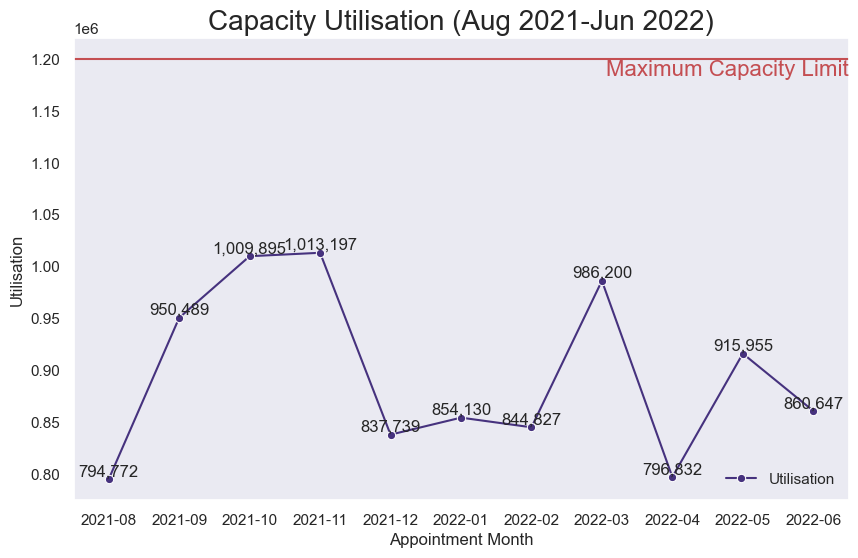

In [487]:
# Plot sum of count of monthly visits and utilisation.
ax = sns.lineplot(x='appointment_month', y='utilisation', data=ar_df, marker='o', label='Utilisation')

# Add data labels to each point.
for index, value in ar_df.iterrows():
    ax.text(value['appointment_month'], value['utilisation'], f'{int(value["utilisation"]):,}',
            ha='center', va='bottom', fontsize=12)

plt.title('Capacity Utilisation (Aug 2021-Jun 2022)', fontsize=20)
plt.xlabel('Appointment Month')
plt.ylabel('Utilisation')

# Show the 1,200,000 appointments limit.
plt.axhline(y=1200000, color='r', linestyle='-', label='Maximum Capacity Limit')
plt.text(plt.xlim()[1], 1200000, 'Maximum Capacity Limit', color='r', ha='right', va='top', fontsize=16)

# Turn off grid lines and show the legend.
plt.grid(False)
plt.savefig('utilisation_ar', dpi=72)
plt.show()

The NHS has the capability to handle a maximum of 1,200,000 appointments per day, and the utilisation column consistently shows that the daily appointment count stays within this limit. While this suggests ample available capacity, it's advisable to closely examine daily visits, especially those exceeding the limit, for a more detailed assessment.

In [488]:
# Determine the number of days with more than 1,200,000 appointments.
# Groupby appointment_date and sum the count_of_appointments.
nc_daily = nc.groupby('appointment_date')['count_of_appointments'].sum().reset_index()

# Filter the DataFrame to include only appointment_date entries with count_of_appointments > 1,200,000.
filtered_app = nc_daily[nc_daily['count_of_appointments'] > 1200000]

# Get the number of appointment_date entries that meet the condition.
num_appointments_above_1200000 = len(filtered_app)

# Determine the total number of unique days in the dataset.
total_unique_days = len(nc['appointment_date'].unique())

# Print the total number of unique days and the number of days with more than 1,200,000 appointments.
print(f'Total number of unique days in the dataset: {total_unique_days}')
print(f'The number of days with more than 1,200,000 appointments is: {num_appointments_above_1200000}')

Total number of unique days in the dataset: 334
The number of days with more than 1,200,000 appointments is: 175


**Out of the 334 days captured in the dataset, 175 days, accounting for 52%, surpass the 1,200,000 daily appointment thresholds, revealing that more than half of the observed days exceeded the capacity limit.**

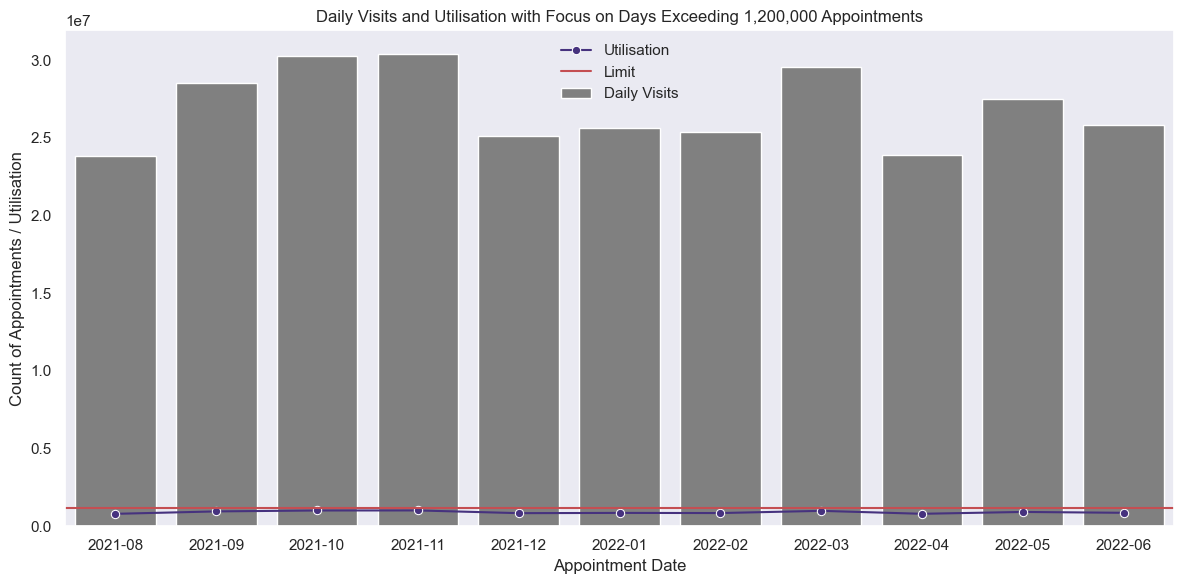

In [489]:
# Plot sum of count of daily visits and utilisation.
plt.figure(figsize=(12, 6))
sns.lineplot(x='appointment_month', y='utilisation', data=ar_df, marker='o', label='Utilisation')
sns.barplot(x='appointment_month', y='count_of_appointments', data=ar_df, color='grey', label='Daily Visits')

# Highlight days exceeding the limit
high_utilisation_days = ar_df[ar_df['utilisation'] > 1200000]
sns.scatterplot(x='appointment_month', y='utilisation', data=high_utilisation_days, color='red', s=50, label='High Utilisation')

plt.title('Daily Visits and Utilisation with Focus on Days Exceeding 1,200,000 Appointments')
plt.xlabel('Appointment Date')
plt.ylabel('Count of Appointments / Utilisation')

# Show the 1,200,000 appointments limit
plt.axhline(y=1200000, color='r', linestyle='-', label='Limit')

# Turn off grid lines and show the legend.
plt.grid(False)
plt.legend()

plt.tight_layout()
plt.savefig('daily_visits_utilisation_ar', dpi=96)
plt.show()

The bar chart clearly illustrates the daily visits and utilization, with a specific emphasis on days surpassing the 1,200,000 appointments limit. It indicates that the NHS experiences a significant daily visit count, consistently exceeding the established limit.

**Question 2:** How do the healthcare professional types differ over time?

In [490]:
# Group by 'hcp_type' and calculate the sum of 'count_of_appointments'.
hcp_type = ar_agg.groupby(['appointment_month', 'hcp_type'])['count_of_appointments'].sum().reset_index()

# Filter out 'Unknown' rows.
hcp_type = hcp_type[hcp_type['hcp_type'] != 'Unknown']

# View the output.
hcp_type

,appointment_month,hcp_type,count_of_appointments
0,2021-08,GP,12296193
1,2021-08,Other Practice staff,10792831
3,2021-09,GP,14484242
4,2021-09,Other Practice staff,13123644
6,2021-10,GP,14298054
7,2021-10,Other Practice staff,14939015
9,2021-11,GP,14893177
10,2021-11,Other Practice staff,14429210
12,2021-12,GP,12651618
13,2021-12,Other Practice staff,11610313


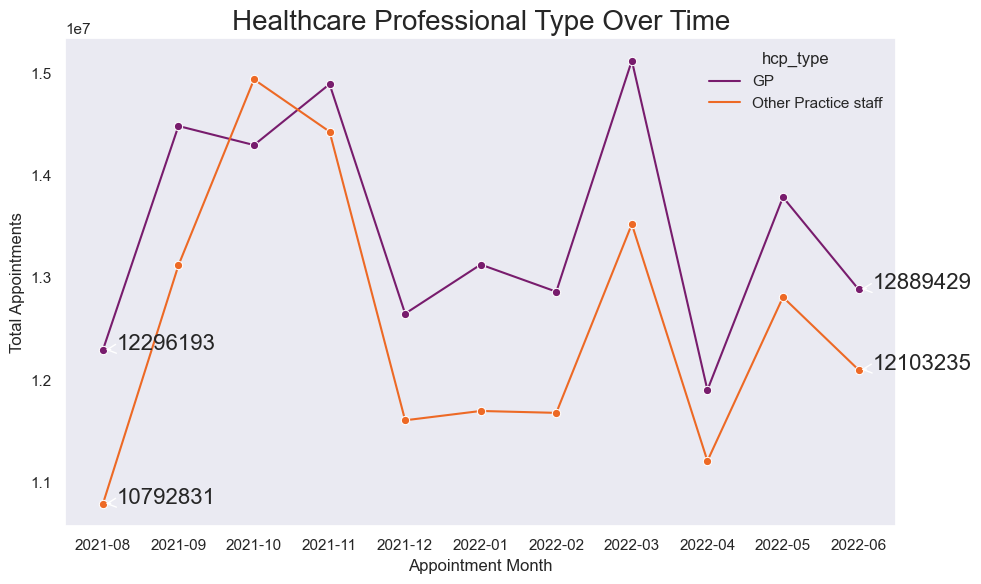

In [491]:
# Create a line plot.
hcp_type_plot = sns.lineplot(x='appointment_month', y='count_of_appointments', hue='hcp_type',\
                             data=hcp_type, marker='o', palette='inferno')

# Set labels and title.
plt.xlabel('Appointment Month')
plt.ylabel('Total Appointments')
plt.title('Healthcare Professional Type Over Time', fontsize=20)

# Add data labels to the first and last points.
for hcp in hcp_type['hcp_type'].unique():
    first_point = hcp_type[hcp_type['hcp_type'] == hcp].iloc[0]
    last_point = hcp_type[hcp_type['hcp_type'] == hcp].iloc[-1]

    plt.annotate(f"{first_point['count_of_appointments']}",
                 xy=(first_point['appointment_month'], first_point['count_of_appointments']),
                 xytext=(10, 0), textcoords='offset points',
                 arrowprops=dict(arrowstyle="->"), fontsize=16)

    plt.annotate(f"{last_point['count_of_appointments']}",
                 xy=(last_point['appointment_month'], last_point['count_of_appointments']),
                 xytext=(10, 0), textcoords='offset points',
                 arrowprops=dict(arrowstyle="->"), fontsize=16)

plt.grid(False)

# Show the plot.
plt.savefig('hcp_type_overtime_ar', dpi=96)
plt.tight_layout()
plt.show()

**After the removal of Covid-19 restrictions, there was a swift surge in the number of appointments for GPs and other practice staff. Among healthcare professional types, 'GP' consistently has the highest monthly appointment count. However, appointments for other practice staff increased more rapidly, reaching a growth of 1.3 million compared to the 600,000 rise for GPs from August 2021 to June 2022.**

**Question 3:** Are there significant changes in the attendance of visits

In [492]:
# Group by 'app_status' and calculate the sum of 'count_of_appointments'.
app_status = ar_agg.groupby(['appointment_month', 'appointment_status'])['count_of_appointments'].sum().reset_index()

# Filter out 'Unknown' rows.
app_status = app_status[app_status['appointment_status'] != 'Unknown']

# View the output.
app_status

,appointment_month,appointment_status,count_of_appointments
0,2021-08,Attended,22080129
1,2021-08,DNA,945115
3,2021-09,Attended,25754396
4,2021-09,DNA,1318764
6,2021-10,Attended,27168570
7,2021-10,DNA,1562842
9,2021-11,Attended,27663843
10,2021-11,DNA,1425992
12,2021-12,Attended,22851041
13,2021-12,DNA,1195622


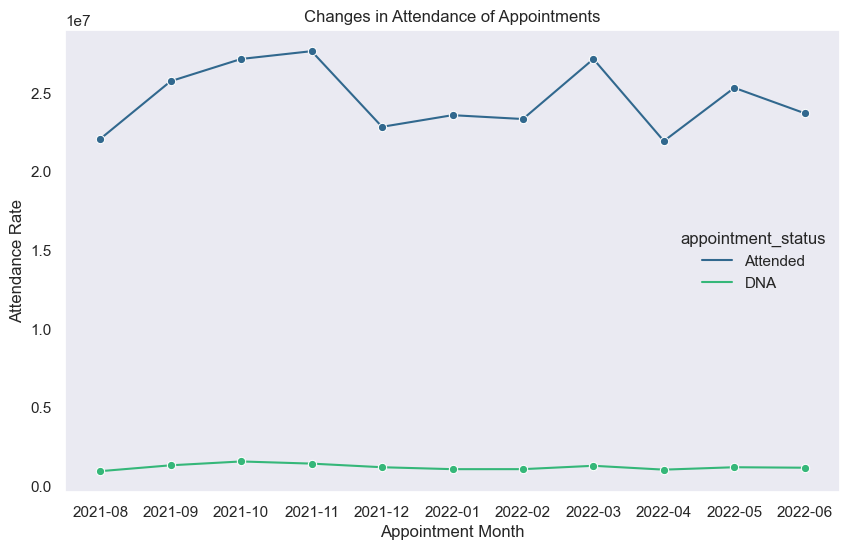

In [493]:
# Create a line plot for attendance over time.
attendance = sns.lineplot(x='appointment_month', y='count_of_appointments', hue='appointment_status',\
                          data=app_status, marker='o', palette='viridis')

# Set labels and title.
plt.xlabel('Appointment Month')
plt.ylabel('Attendance Rate')
plt.title('Changes in Attendance of Appointments')

# Turn off grid lines.
plt.grid(False)

# Save and view the plot.
plt.savefig('changes_in_attendance_ar', dpi=96)
plt.show()

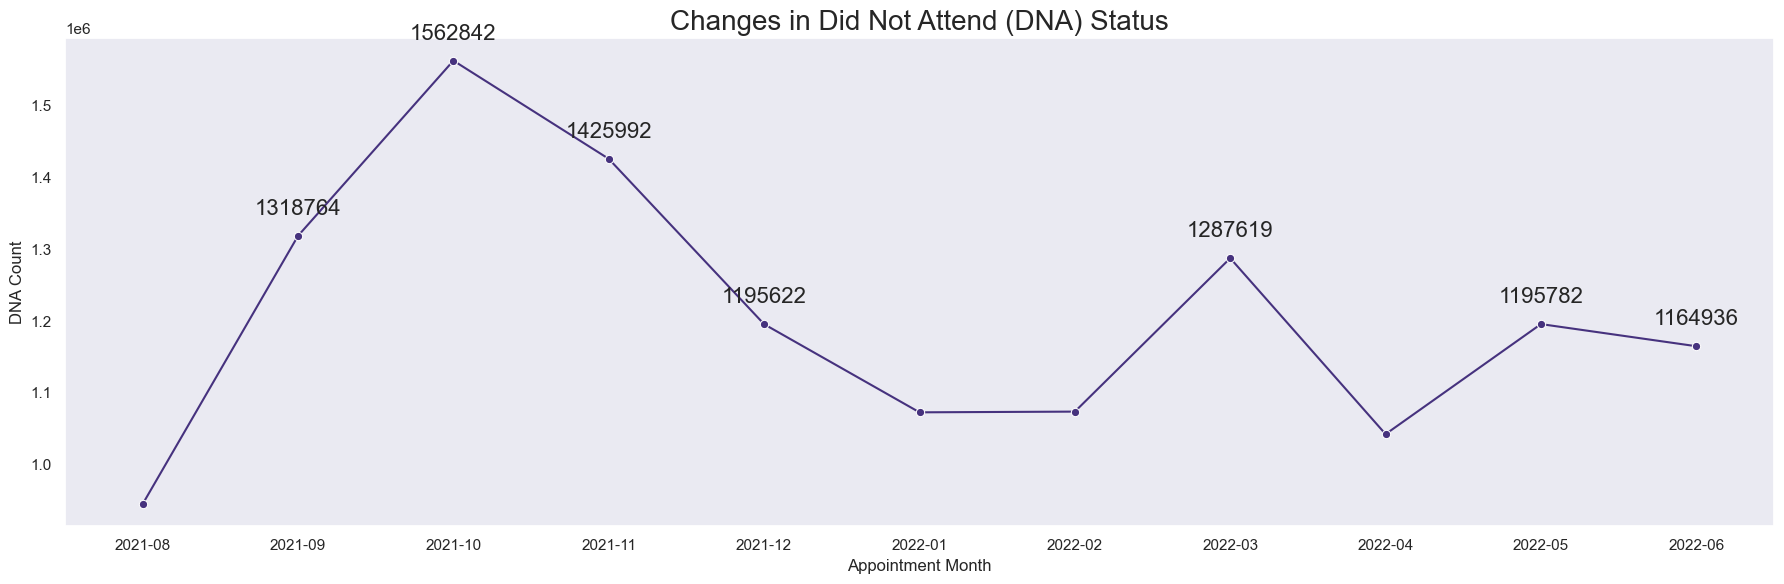

<Figure size 1000x600 with 0 Axes>

In [494]:
# Filter the data for 'DNA' (Did Not Attend) status
plt.figure(figsize=(18, 6))
dna_data = app_status[app_status['appointment_status'] == 'DNA']

# Create a line plot for 'DNA' status over time.
sns.lineplot(x='appointment_month', y='count_of_appointments', data=dna_data, marker='o')

# Set labels and title.
plt.xlabel('Appointment Month')
plt.ylabel('DNA Count')
plt.title('Changes in Did Not Attend (DNA) Status', fontsize=20)

# Turn off grid lines.
plt.grid(False)

# Specify the months for data labels.
specific_months = ['2021-09', '2021-10', '2021-11', '2021-12', '2022-03', '2022-05', '2022-06']

# Add data labels for specific months.
for month in specific_months:
    index = dna_data[dna_data['appointment_month'] == month].index[0]
    count_value = dna_data.loc[index, 'count_of_appointments']
    plt.annotate(f'{count_value}', (month, count_value), textcoords="offset points", xytext=(0, 15), ha='center', fontsize=16)

# View and save the plot.
plt.tight_layout()
plt.show()
plt.savefig('changes_in_dna_status', dpi=96)

**As previously identified, the vast majority, accounting for 91.3%, attended their appointments, with only 4.2% marked as non-attendance. Further examination of data from August 2021 onwards reinforces the observation that a significant majority of patients consistently attend their scheduled appointments. In months with the highest visit numbers which are Sept, Oct and Nov 2021 and March 2022, there is also a corresponding increase in the frequency of patients not attending their appointments.**

**Question 4:** Are there any trends in time between booking an appointment?

In [495]:
# Group by 'time_between_book_and_appointment' and calculate the sum of 'count_of_appointments'.
time_book_app = ar_agg.groupby(['time_between_book_and_appointment'])['count_of_appointments'].sum().reset_index()

# Filter out 'Unknown' rows.
time_book_app = time_book_app[time_book_app['time_between_book_and_appointment'] != 'Unknown / Data Quality']

# Calculate the total appointments count.
total_appointments = ar_agg['count_of_appointments'].sum()

# Calculate the percentage of total appointments for each time category.
time_book_app['percentage_of_appointments'] = (time_book_app['count_of_appointments'] / total_appointments) * 100

# Round the percentage values to one decimal place.
time_book_app = time_book_app.round(1)

# View the output.
time_book_app

,time_between_book_and_appointment,count_of_appointments,percentage_of_appointments
0,1 Day,25854059,8.7
1,15 to 21 Days,19437514,6.6
2,2 to 7 Days,60720229,20.5
3,22 to 28 Days,11417519,3.9
4,8 to 14 Days,37490409,12.7
5,More than 28 Days,9868508,3.3
6,Same Day,130964160,44.3


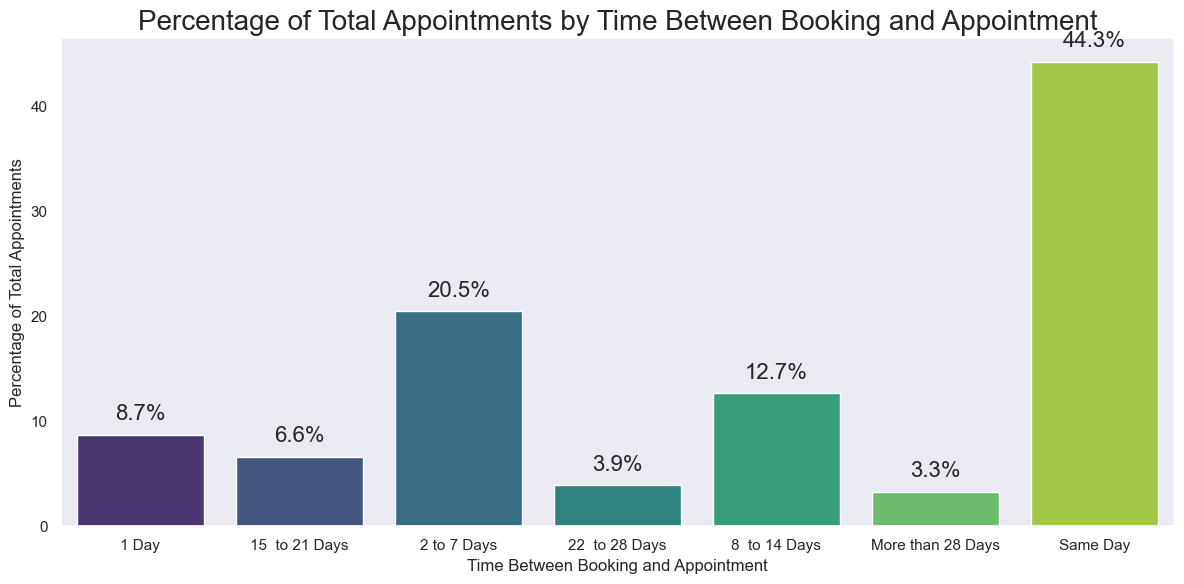

In [496]:
# Create a bar chart.
plt.figure(figsize=(12, 6))
sns.barplot(x='time_between_book_and_appointment', y='percentage_of_appointments', data=time_book_app, palette='viridis')

# Set labels and title.
plt.xlabel('Time Between Booking and Appointment')
plt.ylabel('Percentage of Total Appointments')
plt.title('Percentage of Total Appointments by Time Between Booking and Appointment', fontsize=20)
plt.grid(False)

# Add percentage labels on top of the bars.
for index, value in enumerate(time_book_app['percentage_of_appointments']):
    plt.text(index, value + 1, f'{value}%', ha='center', va='bottom', fontsize=16)

# Show the plot.
plt.tight_layout()
plt.savefig('pecent_timebook_app.png', dpi=96)
plt.show()

**The highest percentage of appointments, 44.3%, are scheduled for the same day, followed by a 20.5% share for appointments within 2 to 7 days.**

In [497]:
# Group by 'time_between_book_and_appointment' and calculate the sum of 'count_of_appointments'.
time_book_app= ar_agg.groupby(['appointment_month', 'time_between_book_and_appointment'])['count_of_appointments']\
.sum().reset_index()

# Filter out 'Unknown' rows.
time_book_app = time_book_app[time_book_app['time_between_book_and_appointment'] != 'Unknown / Data Quality']

# Calculate the total appointments count.
wait_time = ar_agg['count_of_appointments'].sum()

# Calculate the percentage of total appointments for each appointment mode.
am['percentage_of_appointments'] = time_book_app['count_of_appointments'] / total_am_count * 100

# Round the percentage values to one decimal place.
am = am.round(1)

# View the output.
time_book_app

,appointment_month,time_between_book_and_appointment,count_of_appointments
0,2021-08,1 Day,2016779
1,2021-08,15 to 21 Days,1452010
2,2021-08,2 to 7 Days,4923470
3,2021-08,22 to 28 Days,828252
4,2021-08,8 to 14 Days,2886927
...,...,...,...
82,2022-06,2 to 7 Days,4705545
83,2022-06,22 to 28 Days,1216476
84,2022-06,8 to 14 Days,3249100
85,2022-06,More than 28 Days,1065284


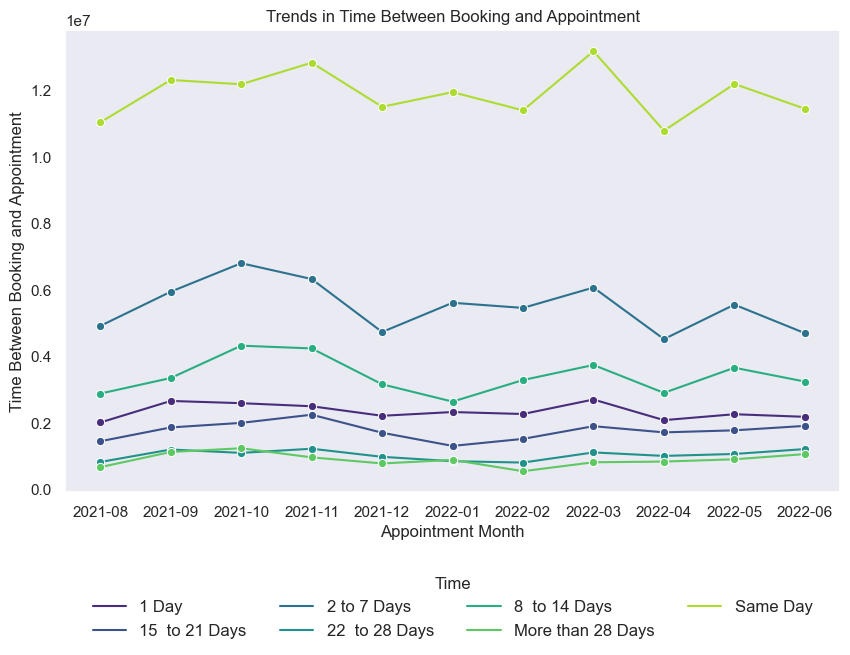

<Figure size 1000x600 with 0 Axes>

In [498]:
# Create a line plot for the time between booking and appointment.
sns.lineplot(x='appointment_month', y='count_of_appointments', hue='time_between_book_and_appointment', \
             data=time_book_app, marker='o', palette='viridis')

# Set labels and title.
plt.xlabel('Appointment Month')
plt.ylabel('Time Between Booking and Appointment')
plt.title('Trends in Time Between Booking and Appointment')

# Change legend title and size and move it to the bottom.
plt.legend(title='Time', bbox_to_anchor=(0.5, -0.15), loc='upper center', ncol=4, fontsize='medium')

# Turn off grid lines.
plt.grid(False)

# Show and save the plot.
plt.show()
plt.savefig('trends_book_appointment', dpi=96)

**In general, the waiting time periods exhibit trends that align with the overall monthly appointment count. Notably, the 'Same Day' category shows a resemblance to the monthly appointment count trend. This may indicate the urgency of situations requiring a 'Same Day' appointment.**

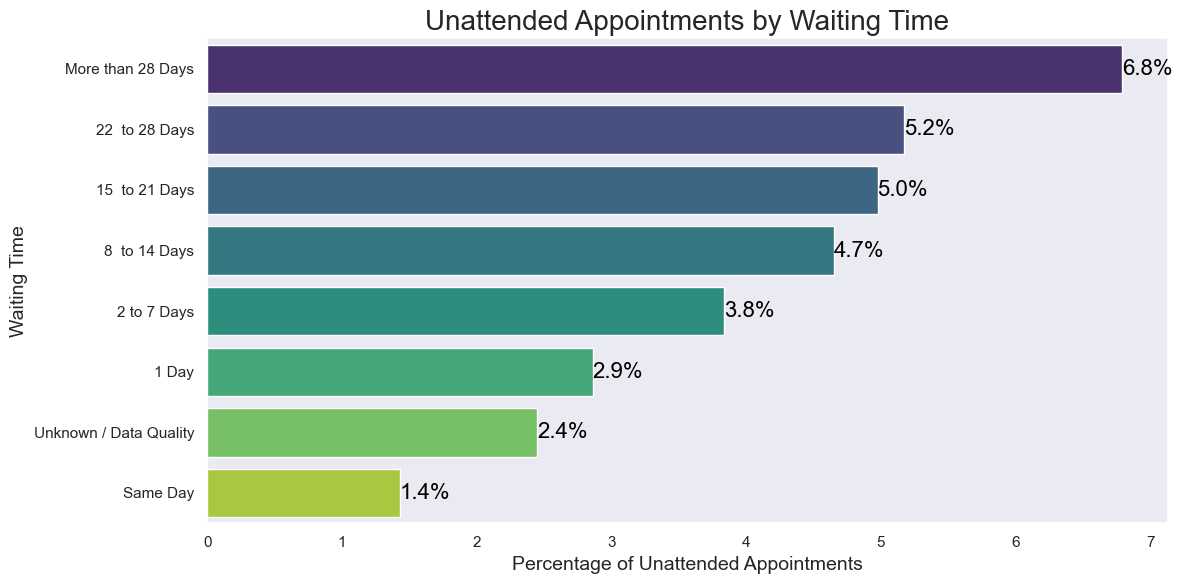

In [499]:
# Filter the data.
plt.figure(figsize=(12, 6))
filt_ar = ar_cleaned[(ar_cleaned['appointment_month'].between('2021-08', '2022-06')) & (ar_cleaned['hcp_type'] == 'GP')]

# Calculate the count_of_appointments.
book_app = filt_ar.groupby('time_between_book_and_appointment')['count_of_appointments'].sum()

# Calculate unattended appointments.
unattended_perc = (filt_ar[filt_ar['appointment_status'] == 'DNA']
                   .groupby('time_between_book_and_appointment')['count_of_appointments']
                   .sum() / book_app) * 100

# Sort the DataFrame in descending order based on the percentage of unattended appointments.
unattended_perc_sorted = unattended_perc.sort_values(ascending=False)

# Create barplot.
avg_unatt_perc_barplot = sns.barplot(x=unattended_perc_sorted.values,
                                     y=unattended_perc_sorted.index,
                                     order=unattended_perc_sorted.index,
                                     palette='viridis')

# Set plot title and labels.
plt.title('Unattended Appointments by Waiting Time', fontsize=20)
plt.xlabel('Percentage of Unattended Appointments', fontsize=14)
plt.ylabel('Waiting Time', fontsize=14)
plt.grid(False)

# Add data points to the barplot.
for index, value in enumerate(unattended_perc_sorted):
    avg_unatt_perc_barplot.text(value, index, f'{value:.1f}%', color='black', ha="left", va="center", fontsize=16)

# Save barplot.
plt.tight_layout()
plt.savefig('avg_unattendedGP.png', dpi=96)
plt.show()

**The correlation observed indicates a positive relationship, suggesting that as the length of patient waiting time for appointments increases, the percentage of non-attendance also tends to increase.**

**Question 5:** Are there changes in terms of appointment type and the busiest months?

In [500]:
# Create a new DataFrame consisting of the appointment mode and the number of appointments.
ar_mode = ar.groupby(['appointment_month', 'appointment_mode'])['count_of_appointments'].sum().reset_index()

# Filter out rows with 'Unknown' and 'Video/Online' appointment modes.
ar_mode_filt = ar_mode[~ar_mode['appointment_mode'].isin(['Unknown', 'Video/Online', 'Home Visit'])]

# View the DataFrame
ar_mode_filt.head()

,appointment_month,appointment_mode,count_of_appointments
0,2020-01,Face-to-Face,21733394
2,2020-01,Telephone,3701775
5,2020-02,Face-to-Face,19230573
7,2020-02,Telephone,3322242
10,2020-03,Face-to-Face,15921794


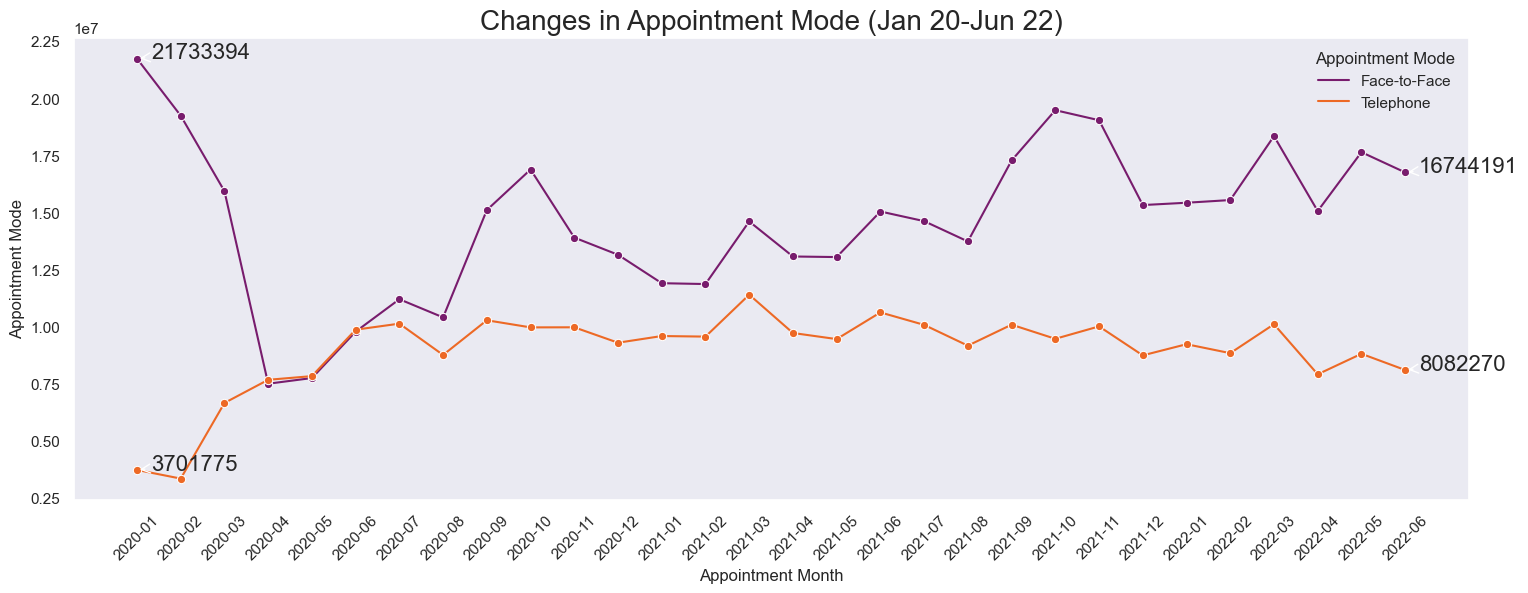

<Figure size 1000x600 with 0 Axes>

In [501]:
# Create a line plot for changes in appointment mode over time.
plt.figure(figsize=(18,6))
sns.lineplot(x='appointment_month', y='count_of_appointments', hue='appointment_mode', \
             data=ar_mode_filt, marker='o', palette='inferno')

# Set labels and title.
plt.xlabel('Appointment Month')
plt.ylabel('Appointment Mode')
plt.title('Changes in Appointment Mode (Jan 20-Jun 22)', fontsize=20)
plt.xticks(rotation=45)
plt.legend(title='Appointment Mode')

# Add data labels to the first and last points.
for mode in ar_mode_filt['appointment_mode'].unique():
    first_point = ar_mode_filt[ar_mode_filt['appointment_mode'] == mode].iloc[0]
    last_point = ar_mode_filt[ar_mode_filt['appointment_mode'] == mode].iloc[-1]

    plt.annotate(f"{first_point['count_of_appointments']}",
                 xy=(first_point['appointment_month'], first_point['count_of_appointments']),
                 xytext=(10, 0), textcoords='offset points',
                 arrowprops=dict(arrowstyle="->"), fontsize=16)

    plt.annotate(f"{last_point['count_of_appointments']}",
                 xy=(last_point['appointment_month'], last_point['count_of_appointments']),
                 xytext=(10, 0), textcoords='offset points',
                 arrowprops=dict(arrowstyle="->"), fontsize=16)

# Turn off grid lines.
plt.grid(False)

# Show and save the plot.
plt.show()
plt.savefig('ar_changes_in_appmode', dpi=96)

**Telephone appointments saw a sharp increase beginning in March 2020, aligning with the start of the first COVID lockdown. Meanwhile, face-to-face appointments experienced a notable decline, especially during the period from January to April 2020. Notably, from January 2020 to June 2022, face-to-face appointments decreased by 5 million, while telephone appointments saw a substantial rise of 4.4 million.**

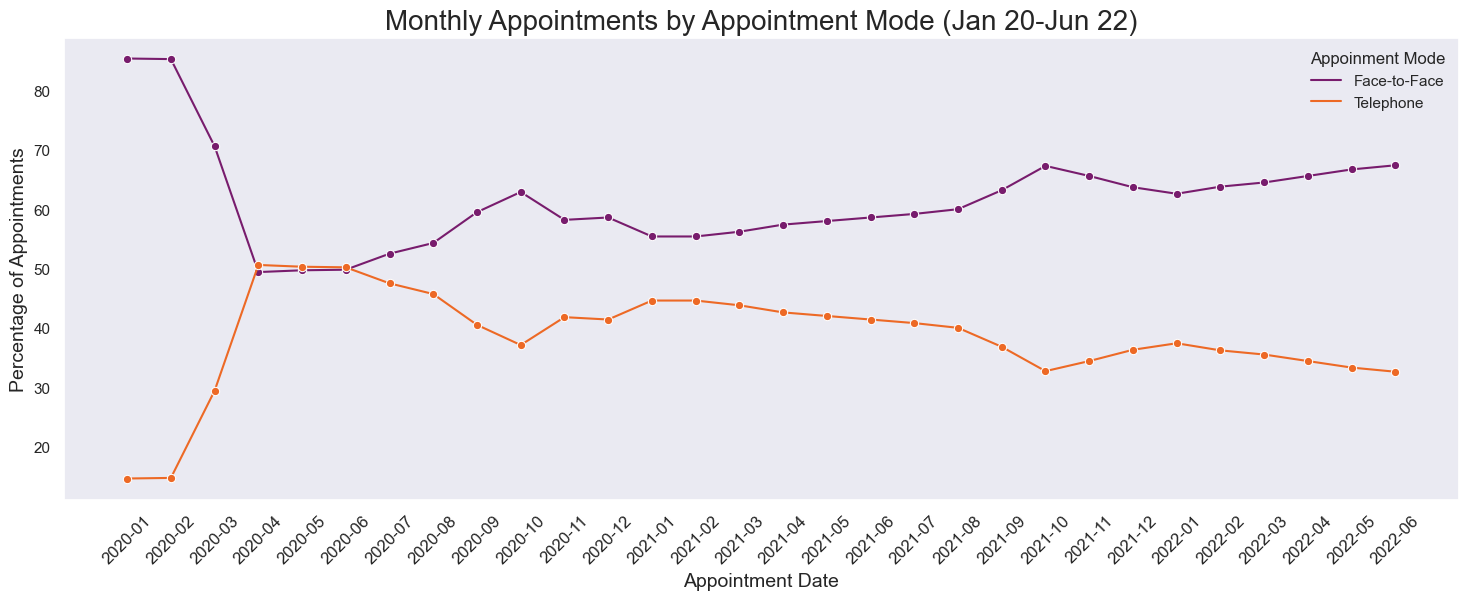

In [502]:
# Calculate the percentage of appointments by appointment mode for each month
plt.figure(figsize=(18,6))
ar_mode_filt['percentage'] = (ar_mode_filt['count_of_appointments'] /
                                ar_mode_filt.groupby('appointment_month')['count_of_appointments']\
                              .transform('sum') * 100).round(1)

# Create a line plot for monthly appointments by appointment mode
sns.lineplot(data=ar_mode_filt, x='appointment_month', y='percentage', hue='appointment_mode', marker='o', palette='inferno')

# Set labels and title
plt.title('Monthly Appointments by Appointment Mode (Jan 20-Jun 22)', fontsize=20)
plt.xlabel('Appointment Date', fontsize=14)
plt.xticks(fontsize=12, rotation=45)
plt.ylabel('Percentage of Appointments', fontsize=14)
plt.legend(title='Appoinment Mode')
plt.grid(False)

# Show the plot
plt.show()

**In January 2020, telephone appointments made up only 15% of the total appointments. However, by April 2020, they became more common than Face-to-Face appointments, accounting for 51%.**

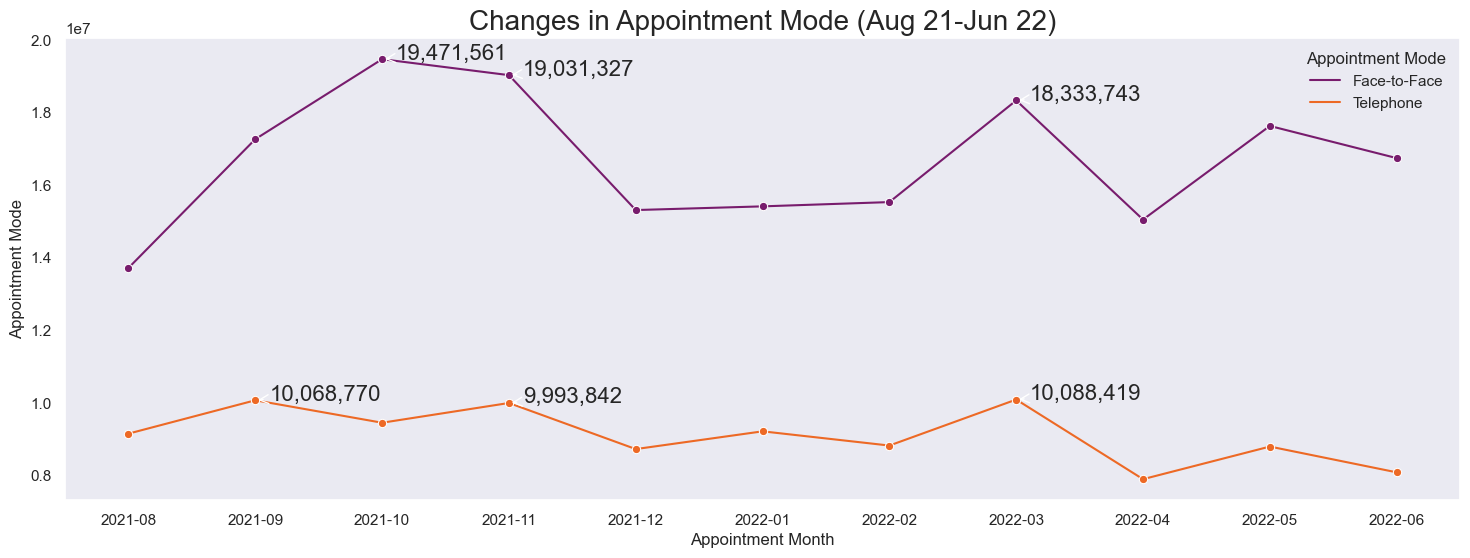

In [503]:
plt.figure(figsize=(18, 6))

# Create and filter a new DataFrame consisting of the appointment mode and the number of appointments.
ar_mode_df = ar_mode.groupby(['appointment_month', 'appointment_mode'])['count_of_appointments'].sum().reset_index()

filtered_ar_mode = ar_mode_df[(ar_mode_df['appointment_month'] >= '2021-08') & \
                              ~ar_mode_df['appointment_mode'].isin(['Unknown', 'Home Visit', 'Video/Online'])]

ax = sns.lineplot(x='appointment_month', y='count_of_appointments', hue='appointment_mode',
                  data=filtered_ar_mode, marker='o', palette='inferno')

# Set labels and title.
plt.xlabel('Appointment Month')
plt.ylabel('Appointment Mode')
plt.title('Changes in Appointment Mode (Aug 21-Jun 22)', fontsize=20)
plt.legend(title='Appointment Mode')

# Add data labels to the five highest points for each appointment mode.
for mode in filtered_ar_mode['appointment_mode'].unique():
    mode_data = filtered_ar_mode[filtered_ar_mode['appointment_mode'] == mode]
    top5_highest = mode_data.nlargest(3, 'count_of_appointments')

    for index, value in top5_highest.iterrows():
        count_label = f'{int(value["count_of_appointments"]):,}'
        ax.annotate(count_label,
                    xy=(value['appointment_month'], value['count_of_appointments']),
                    xytext=(10, 0), textcoords='offset points',
                    arrowprops=dict(arrowstyle="->"), fontsize=16)

# Turn off grid lines.
plt.grid(False)

# Show and save the plot.
plt.savefig('ar_appmode', dpi=96)
plt.show()

**Since the most Covid restriction ended, there has been a gradual shift back towards Face-to-Face appointments, although they are still not as common as before.**

**Question 6:** How do the various service settings compare?

In [504]:
print(nc.columns)

Index(['appointment_date', 'icb_ons_code', 'sub_icb_location_name',
       'service_setting', 'context_type', 'national_category',
       'count_of_appointments', 'appointment_month', 'day_of_week'],
      dtype='object')


In [505]:
# Create a new DataFrame consisting of the month of appointment and the number of appointments.
nc_df = nc.groupby(['appointment_month', 'service_setting'])['count_of_appointments'].sum().reset_index()

# View the DataFrame
nc_df.head()

,appointment_month,service_setting,count_of_appointments
0,2021-08-01,Extended Access Provision,160927
1,2021-08-01,General Practice,21575852
2,2021-08-01,Other,449101
3,2021-08-01,Primary Care Network,432448
4,2021-08-01,Unmapped,1233843


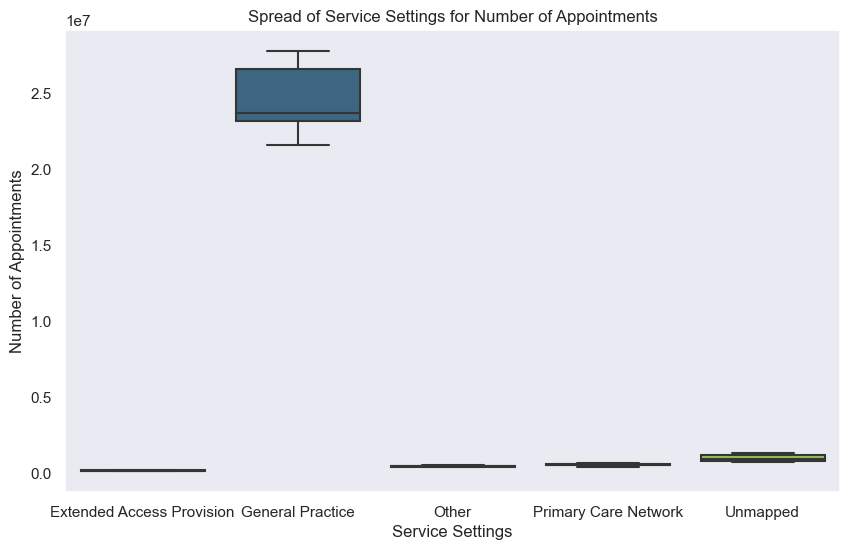

<Figure size 1000x600 with 0 Axes>

In [506]:
# Create a boxplot to investigate the spread of service settings.
sns.boxplot(x='service_setting', y='count_of_appointments', data=nc_df, palette='viridis')

# Set labels and title
plt.xlabel('Service Settings')
plt.ylabel('Number of Appointments')
plt.title('Spread of Service Settings for Number of Appointments')

plt.grid(False)

# Show and save the plot.
plt.show()
plt.savefig('spread_of_ss', dpi=96)

**Earlier analysis revealed that General Practice consistently held the majority share of appointments, comprising 91.5%, during the Covid-19 period and continuing to be the primary category from August 2021 onwards.**

<Figure size 1200x600 with 0 Axes>

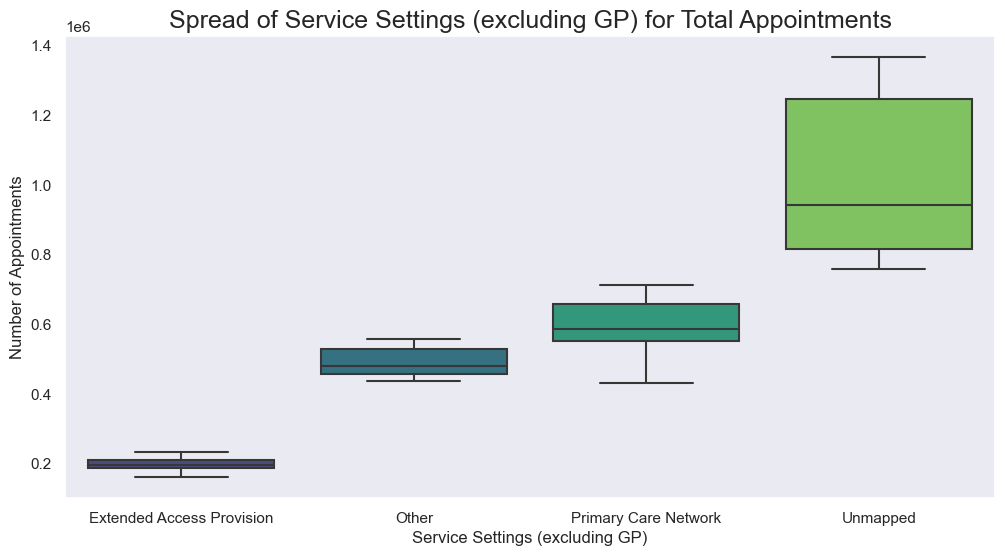

<Figure size 1000x600 with 0 Axes>

In [507]:
# Create a boxplot to investigate the service settings without GP.
# Filter out GP service setting.
plt.figure(figsize=(12, 6))
nc_no_gp = nc_df[nc_df['service_setting'] != 'General Practice']

# Create a boxplot.
plt.figure(figsize=(12, 6))
sns.boxplot(x='service_setting', y='count_of_appointments', data=nc_no_gp, palette='viridis')

# Set labels and title
plt.xlabel('Service Settings (excluding GP)')
plt.ylabel('Number of Appointments')
plt.title('Spread of Service Settings (excluding GP) for Total Appointments', fontsize=18)
plt.grid(False)

# Show and save the plot
plt.show()
plt.savefig('spread_of_ss_noGP', dpi=96)

**Excluding General Practice, the appointments in unmapped service settings have surpassed 1 million, making them the highest since August 2021.**

>### Recommendations

    
 **Increase Early Week Staffing:** Allocate more staff earlier in the week to handle the higher demand during the busiest months.
 
 **Weekend Availability:** Consider extending staff availability on weekends to accommodate the demand for appointments.
 
 **Promote Telephone Appointments:** Given the consistent demand throughout the year and during busy times, encourage the use of telephone appointments where appropriate. This could be a more efficient use of resources and provide flexibility for both staff and patients.
    
 **Same-Day Appointments:** Given that same-day appointments are attended the most, prioritize scheduling and promoting same-day appointments to increase attendance rates.
    
 **Shorten Booking-to-Appointment Time:** Keep the time between booking and the actual appointment as short as possible to enhance attendance rates.
    
 **Patient Preferences:** Conduct consultations with patients to understand their preferences for appointment types and times. This information can be valuable in tailoring the scheduling system to better match patient needs and reduce missed appointments.
    
 **Explore Online Scheduling:** If not already in place, consider implementing an online scheduling system that allows patients to book appointments conveniently. This can enhance accessibility and streamline the booking process.
    
 **Regularly Review Data:** Continuously monitor appointment data to identify trends and adjust scheduling practices accordingly. Regular evaluations will help in adapting to changing demands and optimizing resource allocation.
